# **GeoMarket AI — Notebook 01: DBSCAN Spatial Clustering**

**Tujuan notebook ini:**  
Menghasilkan `cluster_id` untuk setiap titik lokasi usaha di Batam menggunakan algoritma DBSCAN berbasis kepadatan spasial. Output `cluster_id` ini akan menjadi salah satu **fitur input utama** untuk training Random Forest di notebook berikutnya.

**Catatan penting:**  
Notebook ini dijalankan **per database** (satu DB per run) untuk mengurangi noise lintas sumber.

**Ringkasan pipeline (caption per tahap):**
- **Tahap 1** — Install & import library
- **Tahap 2** — EDA: scan file, cek skema, mapping kolom, merge data, verifikasi
- **Tahap 3** — Konfigurasi & konstanta (parameter DBSCAN dan path)
- **Tahap 4** — Ingestion & validation gate (data quality report)
- **Tahap 5** — Preprocessing & konversi koordinat (WGS84 -> UTM)
- **Tahap 6** — DBSCAN clustering + evaluasi + fitur turunan
- **Tahap 7** — Visualisasi hasil clustering & tuning EPS
- **Tahap 8** — Simpan ke feature store
- **Tahap 9** — Quality gate DBSCAN
- **Tahap 10** — Random Forest training (label proxy + evaluasi + SHAP)

**Posisi dalam MLOps Pipeline:**
```
SQLite (.db)
    └─ [01] Ingestion & Validation        <- tahap 1-2
    └─ [02] Preprocessing & Feature Eng   <- tahap 3
    └─ [03] DBSCAN Clustering             <- tahap 4-5  (inti notebook ini)
    └─ [04] Simpan ke Feature Store       <- tahap 6
            └─ [Notebook 02] Random Forest Training
```

| Algoritma | DBSCAN (Density-Based Spatial Clustering of Applications with Noise) |
|---|---|
| Input | `content/data/raw/*.db` (1 DB per run) |
| Output | `content/runs/<db_key>/data/feature_store.csv` |

**Mengapa DBSCAN harus jalan SEBELUM Random Forest?**  
Karena `cluster_id` dan `dist_to_cluster_centroid_m` adalah fitur yang hanya bisa dihasilkan setelah clustering selesai. Random Forest tidak bisa dilatih tanpa kedua fitur ini.

---

---
# Tahap 1 — Install & Import Library

Kita butuh beberapa library tambahan di luar standard library Python:
- `geopandas` + `pyproj` → untuk konversi koordinat dari derajat (WGS84) ke meter (UTM), wajib untuk perhitungan radius yang akurat
- `scikit-learn` → untuk DBSCAN dan metrik evaluasi clustering
- `scipy` → untuk perhitungan jarak spasial
- `folium` → opsional, untuk visualisasi peta interaktif

In [1]:
# ── 1.1 Install Libraries ──────────────────────────\n
%pip install scikit-learn matplotlib geopandas pyproj folium seaborn pyarrow osmnx fastjsonschema --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
# ── 1.2 Import & Core ──────────────────────────
import sqlite3
import os
import json
import warnings
warnings.filterwarnings('ignore')

# ── Data manipulation ─────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Geospasial ────────────────────────────────────────────────────────
import geopandas as gpd
from pyproj import Transformer
from shapely.geometry import Point

# ── Machine Learning ──────────────────────────────────────────────────
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler

# ── Visualisasi ───────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm

# Cek versi
print(f"pandas      : {pd.__version__}")
print(f"numpy       : {np.__version__}")
print(f"geopandas   : {gpd.__version__}")
print(f"scikit-learn: {__import__('sklearn').__version__}")
print("\n✓ Semua library berhasil diimport")

pandas      : 3.0.2
numpy       : 2.4.4
geopandas   : 1.1.3
scikit-learn: 1.8.0

✓ Semua library berhasil diimport


# Tahap 2 — Exploratory Data Analysis (EDA)

Tujuan: memahami struktur data, skema, dan sebaran awal sebelum validasi.

## 2.1 Scan file dataset .db

Ringkas: daftar file, kategori, dan ukuran untuk memastikan input lengkap.

In [17]:
import os
import glob

# ── 2.1 Konfigurasi folder & validasi ────────────────
DB_FOLDER = "content/data/raw"

# ── Pilih satu DB untuk satu run ──────────────────────────────────────
TARGET_DB_FILE = "Indonesia.Batam.Kuliner.202406162232.db"

CATEGORY_MAPPING = {
    "Indonesia.Batam.Kuliner.202406162232"       : "F&B",
    "Indonesia.Batam.Kesehatan.202408050759"     : "Healthcare",
    "Indonesia.Batam.Hotel.202408042041"         : "Hospitality",
    "Indonesia.Batam.PT.202408042212"            : "Company",
    "Indonesia.Batam.School.202408060757"        : "Education",
    "Indonesia.Batam.Toko Bangunan.202408021219" : "Retail",
    "Indonesia.Batam.Cosmetics.202410290644"     : "Retail",
    "Indonesia.Batam.Toko Komputer.202410170720" : "Retail",
}

# ── Scan semua file .db (untuk validasi) ──────────────────────────────
all_db_files = sorted(glob.glob(os.path.join(DB_FOLDER, "*.db")))

if not all_db_files:
    print(f"⚠ Tidak ada file .db ditemukan di folder: {DB_FOLDER}")
    print("  Pastikan path DB_FOLDER sudah benar.")
else:
    if not TARGET_DB_FILE:
        raise ValueError("TARGET_DB_FILE belum diisi. Pilih satu file .db untuk diproses.")

    target_path = os.path.join(DB_FOLDER, TARGET_DB_FILE)
    if not os.path.exists(target_path):
        available = [os.path.basename(p) for p in all_db_files]
        raise FileNotFoundError(
            f"TARGET_DB_FILE tidak ditemukan: {TARGET_DB_FILE}\n"
            f"File tersedia: {available}"
        )

    db_files = [target_path]
    filename = os.path.basename(target_path)
    file_key = filename.replace(".db", "")
    TARGET_DB_KEY = file_key
    size_kb = os.path.getsize(target_path) / 1024

    # Lookup ke CATEGORY_MAPPING
    if file_key in CATEGORY_MAPPING:
        kategori = CATEGORY_MAPPING[file_key]
        status = "✓"
    else:
        parts = file_key.split(".")
        kategori = parts[2] if len(parts) >= 3 else "Unknown"
        status = "⚠"

    print(f"✓ Target DB: {TARGET_DB_FILE}\n")
    print(f"  {status} {filename:<47} → {kategori:<15} ({size_kb:.1f} KB)")

✓ Target DB: Indonesia.Batam.Kuliner.202406162232.db

  ✓ Indonesia.Batam.Kuliner.202406162232.db         → F&B             (4080.0 KB)


## 2.2 Peek skema tiap file

Ringkas: cek tabel user, jumlah baris, dan contoh kolom per database.

In [18]:
import sqlite3
import pandas as pd
import os
from IPython.display import display, HTML

# ── 2.2 Peek skema & tabel internal ─────────────────
SQLITE_INTERNAL_TABLES = {'sqlite_sequence', 'sqlite_stat1', 'sqlite_stat4', 'sqlite_master'}

schema_summary = []

for db_path in db_files:
    filename = os.path.basename(db_path)
    file_key = filename.replace(".db", "")
    parts = file_key.split(".")
    kategori = CATEGORY_MAPPING.get(file_key, parts[2] if len(parts) >= 3 else "Unknown")

    conn = sqlite3.connect(db_path)

    # Ambil daftar tabel
    tables_df = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
    tables = tables_df['name'].tolist()

    # Filter tabel
    user_tables = [t for t in tables if t not in SQLITE_INTERNAL_TABLES]

    # --- HEADER FILE ---
    display(HTML(f"""
    <div style="background-color: #f8f9fa; padding: 10px; border-left: 5px solid #28a745; margin-top: 20px;">
        <span style="font-weight: bold; font-size: 16px; color: #6c757d;">File: {filename}</span><br>
        <span style="color: #6c757d;">Kategori: <b>{kategori}</b> | Tabel User: {len(user_tables)}</span>
    </div>
    """))

    for table in user_tables:
        try:
            # Ambil sampel dan jumlah baris
            df_peek = pd.read_sql(f"SELECT * FROM [{table}] LIMIT 10", conn)
            row_count = pd.read_sql(f"SELECT COUNT(*) as n FROM [{table}]", conn)['n'].iloc[0]

            schema_summary.append({
                "Filename": filename,
                "Category": kategori,
                "Table": table,
                "Rows": row_count,
                "Total Column": len(df_peek.columns)
            })

            # Tampilkan info tabel dan sampel
            print(f"\n📍 Tabel: {table} ({row_count:,} baris)")
            display(df_peek)

        except Exception as e:
            print(f"  ⚠️ Gagal baca tabel '{table}': {e}")

    conn.close()

# --- BAGIAN AKHIR: RINGKASAN SELURUH FILE ---
print("\n" + "="*60)
print("📊 RINGKASAN SCHEMA KESELURUHAN")
print("="*60)

df_final_summary = pd.DataFrame(schema_summary)

if not df_final_summary.empty:
    # Format ribuan untuk tampilan profesional
    df_final_summary['Rows'] = df_final_summary['Rows'].apply(lambda x: "{:,}".format(x))
    display(df_final_summary)
else:
    print("Tidak ada tabel user yang ditemukan.")

print(f"\n✅ Inspeksi Selesai: {len(db_files)} file diproses.")


📍 Tabel: places (4,570 baris)


,id,name,rating,review,price_level,category,services,address,open_hours,phone,latitude,longitude,url,cluster
0,96,Pacific food court,4.4,233,2,Restaurant,"['Dine-in', 'Takeaway']","5222+C65, Jodoh River, Batu Ampar, Batam City,...",[],,1.151015,104.0006023,https://www.google.com/maps/place/Pacific+food...,2.0
1,193,Berjaya Masakan Padang,4.0,3,0,Padang restaurant,"['Dine-in', 'Takeaway']","5234+P57, Jodoh River, Batu Ampar, Batam City,...","[{ day: 'Sunday', hours: '09:00 – 21:00' }, { ...",,1.1542775,104.005409,https://www.google.com/maps/place/Berjaya+Masa...,0.0
2,211,Warung Kopi HARUM,4.4,303,0,Noodle shop,"['Dine-in', 'Takeaway']","5226+2HQ, Jodoh River, Batu Ampar, Batam City,...","[{ day: 'Sunday', hours: '06:00 – 14:00' }, { ...",,1.1500874,104.0114747,https://www.google.com/maps/place/Warung+Kopi+...,2.0
3,230,Toko Barokah,4.0,5,0,Grocery store,['In-store shopping'],"52M7+8FM, Batu Merah, Batu Ampar, Batam City, ...","[{ day: 'Sunday', hours: '07:00 – 21:00' }, { ...",,1.1833464,104.0136583,https://www.google.com/maps/place/Toko+Barokah...,2.0
4,240,Multi Bintang Indonesia,4.5,2,0,Grocery delivery service,[],"5296+42F, Batu Merah, Batu Ampar, Batam City, ...",[],,1.1678122,104.0100557,https://www.google.com/maps/place/Multi+Bintan...,3.0
5,257,Ampera nasi padang Ombak piaman,0.0,0,0,Padang restaurant,"['Dine-in', 'Takeaway']","5243+3P8, Jodoh River, Batu Ampar, Batam City,...","[{ day: 'Sunday', hours: '08:00 – 21:30' }, { ...",,1.155156,104.0043247,https://www.google.com/maps/place/Ampera+nasi+...,0.0
6,282,Pak Bas Kue & Kripic,4.0,2,0,Food products supplier,[],"52P5+VP2, Batu Merah, Batu Ampar, Batam City, ...","[{ day: 'Sunday', hours: '06:00 – 22:00' }, { ...",+62 812-7742-6621,1.1871409,104.0092639,https://www.google.com/maps/place/Pak+Bas+Kue+...,2.0
7,292,Seblak Teh Senny - Bengkong,3.4,28,0,Buffet restaurant,"['Dine-in', 'Takeaway', 'Delivery']","Pertokoan Jl. Ruko Golden City Blok F No. 6, B...","[{ day: 'Sunday', hours: '03:00 – 23:00' }, { ...",+62 821-7132-0270,1.1655638,104.0393071,https://www.google.com/maps/place/Seblak+Teh+S...,2.0
8,299,SOTO LAMONGAN CAK ALI,4.4,13,0,Soto ayam restaurant,"['Dine-in', 'Takeaway']","Komplek Maritim Square Jodoh, Blk. I No.21, RT...","[{ day: 'Sunday', hours: '11:00 – 21:00' }, { ...",,1.153548,104.0054803,https://www.google.com/maps/place/SOTO+LAMONGA...,-1.0
9,303,Bina Nusa Mandiri PT,0.0,0,0,Caterer,[],"Bukit Senyum, Batu Ampar, Komplek Malindo Cipt...",[],,1.1688287,104.0112953,https://www.google.com/maps/place/Bina+Nusa+Ma...,5.0



📊 RINGKASAN SCHEMA KESELURUHAN


,Filename,Category,Table,Rows,Total Column
0,Indonesia.Batam.Kuliner.202406162232.db,F&B,places,"4,570",14



✅ Inspeksi Selesai: 1 file diproses.


## 2.3 Definisi mapping kolom

Ringkas: samakan nama kolom kunci agar semua sumber konsisten.

In [19]:
# ── 2.3 Standarisasi nama kolom ───────────────────
# agar semua file memiliki nama kolom yang seragam setelah digabung.
#
# Ubah mapping di bawah sesuai hasil inspeksi Cell 2.2
# Key   = nama kolom ASLI di database
# Value = nama kolom STANDAR yang akan digunakan di Feature Store
#
# Kolom yang tidak ada di mapping akan tetap dipertahankan dengan
# nama aslinya.

COLUMN_MAPPING = {
    # Koordinat — sesuaikan jika nama kolom berbeda
    "lat"       : "latitude",
    "lng"       : "longitude",
    "lon"       : "longitude",
    "long"      : "longitude",

    # Nama tempat — sesuaikan jika nama kolom berbeda
    "nama"      : "name",
    "place_name": "name",
    "title"     : "name",

    # Kategori
    "cat"       : "category",
    "type"      : "category",
    "jenis"     : "category",

    # Rating & review
    "rate"      : "rating",
    "score"     : "rating",
    "ulasan"    : "reviews",
    "review_count": "reviews",
    "total_reviews": "reviews",

    # Tambahkan mapping lain sesuai kebutuhan
    # "nama_kolom_asli": "nama_kolom_standar",
}

# Kolom wajib yang harus ada setelah mapping
REQUIRED_COLS_FINAL = ["latitude", "longitude", "name", "category"]

# Nama kolom latitude & longitude yang akan digunakan (setelah mapping)
LAT_COL = "latitude"
LON_COL = "longitude"
CAT_COL = "category"

print("Mapping kolom yang akan diterapkan:")
for k, v in COLUMN_MAPPING.items():
    print(f"  '{k}' → '{v}'")
print(f"\nKolom wajib setelah mapping: {REQUIRED_COLS_FINAL}")

Mapping kolom yang akan diterapkan:
  'lat' → 'latitude'
  'lng' → 'longitude'
  'lon' → 'longitude'
  'long' → 'longitude'
  'nama' → 'name'
  'place_name' → 'name'
  'title' → 'name'
  'cat' → 'category'
  'type' → 'category'
  'jenis' → 'category'
  'rate' → 'rating'
  'score' → 'rating'
  'ulasan' → 'reviews'
  'review_count' → 'reviews'
  'total_reviews' → 'reviews'

Kolom wajib setelah mapping: ['latitude', 'longitude', 'name', 'category']


## 2.4 Gabungkan semua .db jadi Dataframe

Ringkas: load seluruh tabel dan gabungkan ke satu DataFrame.

Memulai proses penggabungan data (single DB)...

📊 LAPORAN AUDIT DATA:


,File Name,Category,Table,Rows Raw,Rows Kept,Rows Dropped
0,Indonesia.Batam.Kuliner.202406162232.db,F&B,places,4570,4570,0



JUMLAH BARIS KONSISTEN
------------------------------------------------------------
Total Baris di DataFrame : 4,570
Total Baris Raw (Sum)    : 4,570
Total Baris Kept (Sum)   : 4,570
------------------------------------------------------------

Tabel distribusi kategori (Top 10):


,Kategori,Jumlah
0,Restaurant,1290
1,Indonesian restaurant,253
2,Padang restaurant,169
3,Seafood restaurant,148
4,Bakso restaurant,147
5,Diner,138
6,Noodle shop,114
7,Cafe,98
8,Chicken restaurant,95
9,Coffee shop,95


Distribusi penuh disimpan: content\runs\Indonesia.Batam.Kuliner.202406162232\data\category_distribution.json


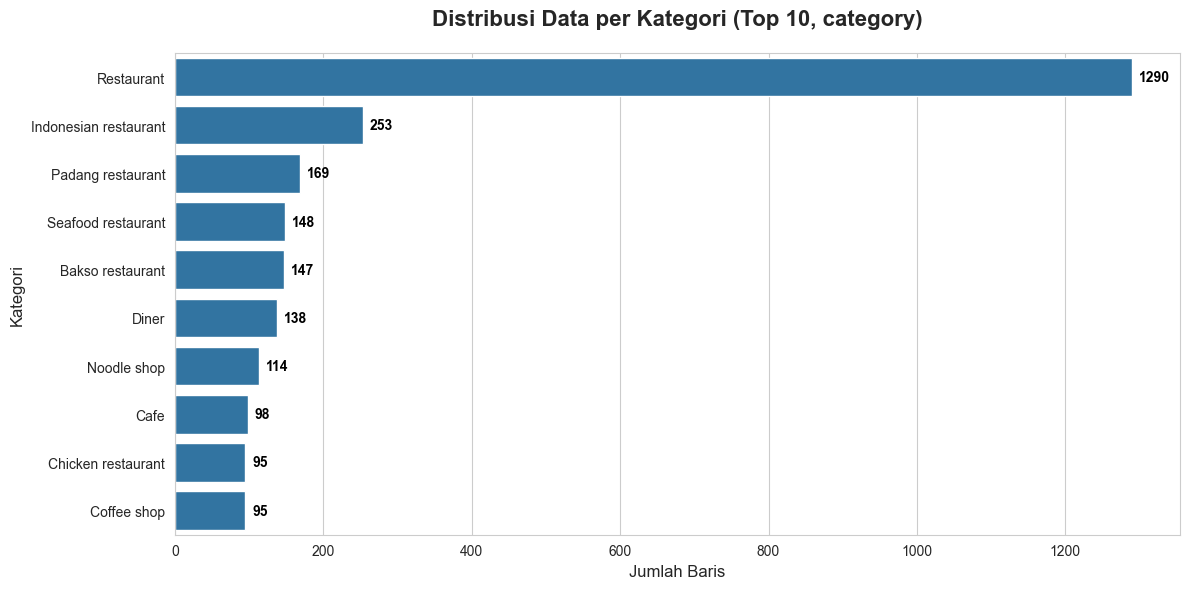

In [20]:
import pandas as pd
import sqlite3
import os
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

frames = []
load_report = []

def _normalize_text(series: pd.Series) -> pd.Series:
    cleaned = series.astype(str).str.strip()
    cleaned = cleaned.replace({"": pd.NA, "nan": pd.NA, "None": pd.NA, "none": pd.NA})
    return cleaned

def preprocess_table(df_temp: pd.DataFrame, source_cat: str, filename: str, table: str) -> pd.DataFrame:
    df_temp = df_temp.rename(columns=COLUMN_MAPPING)

    df_temp["source_category"] = source_cat
    df_temp["source_file"] = filename
    df_temp["source_table"] = table

    if "category" not in df_temp.columns:
        df_temp["category"] = pd.NA

    for col in ["name", "category"]:
        if col in df_temp.columns:
            df_temp[col] = _normalize_text(df_temp[col])

    for col in ["latitude", "longitude", "rating", "reviews", "review"]:
        if col in df_temp.columns:
            df_temp[col] = pd.to_numeric(df_temp[col], errors="coerce")

    required_cols = ["latitude", "longitude", "name", "category"]
    required_present = [c for c in required_cols if c in df_temp.columns]
    rows_before = len(df_temp)
# ── 2.4 Load dan Gabungkan Semua Tabel ───────────────
    rows_after = len(df_temp)

    return df_temp, rows_before, rows_after

print("Memulai proses penggabungan data (single DB)...")

# --- PROSES PEMBACAAN DATA ---
for db_path in db_files:
    filename = os.path.basename(db_path)
    file_key = filename.replace(".db", "")

    # Ambil kategori (Contoh logika: mapping atau fallback)
    source_cat = CATEGORY_MAPPING.get(file_key, "Unknown")

    try:
        conn = sqlite3.connect(db_path)
        tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)['name'].tolist()
        user_tables = [t for t in tables if t not in SQLITE_INTERNAL_TABLES]

        for table in user_tables:
            df_temp = pd.read_sql(f"SELECT * FROM [{table}]", conn)
            df_temp, rows_before, rows_after = preprocess_table(
                df_temp, source_cat, filename, table
            )
            frames.append(df_temp)
            load_report.append({
                "File Name": filename,
                "Category": source_cat,
                "Table": table,
                "Rows Raw": rows_before,
                "Rows Kept": rows_after,
                "Rows Dropped": rows_before - rows_after,
            })
        conn.close()
    except Exception as e:
        print(f"Gagal memproses {filename}: {e}")

if not frames:
    raise ValueError("Tidak ada data yang berhasil dimuat dari DB target.")

# Gabungkan Data
df_raw = pd.concat(frames, ignore_index=True)
df_report = pd.DataFrame(load_report)

# --- VISUALISASI 1: TABEL LAPORAN (Styled) ---
print("\n📊 LAPORAN AUDIT DATA:")
total_raw = int(df_report["Rows Raw"].sum()) if not df_report.empty else 0
total_kept = int(df_report["Rows Kept"].sum()) if not df_report.empty else 0
actual_rows = len(df_raw)
is_consistent = actual_rows == total_kept

display(df_report)

# --- VISUALISASI 2: STATUS INTEGRITAS (HTML Box) ---
status_text = "JUMLAH BARIS KONSISTEN" if is_consistent else f"⚠️ SELISIH DATA: {abs(actual_rows - total_kept)} baris!"
print(f"\n{status_text}")
print(f"{'-'*60}")
print(f"Total Baris di DataFrame : {actual_rows:,}")
print(f"Total Baris Raw (Sum)    : {total_raw:,}")
print(f"Total Baris Kept (Sum)   : {total_kept:,}")
print(f"{'-'*60}")

# --- VISUALISASI 3: GRAFIK DISTRIBUSI (Matplotlib/Seaborn) ---
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

dist_col = CAT_COL if CAT_COL in df_raw.columns else "source_category"
dist_full = df_raw[dist_col].value_counts().reset_index()
dist_full.columns = ['Kategori', 'Jumlah']

print("\nTabel distribusi kategori (Top 10):")
display(dist_full.head(10))

run_dir = os.path.join("content", "runs", TARGET_DB_KEY if "TARGET_DB_KEY" in globals() else "unknown_run")
data_dir = os.path.join(run_dir, "data")
os.makedirs(data_dir, exist_ok=True)
if len(dist_full) > 10:
    dist_json_path = os.path.join(data_dir, "category_distribution.json")
    dist_full.to_json(dist_json_path, orient="records", force_ascii=True, indent=2)
    print(f"Distribusi penuh disimpan: {dist_json_path}")

dist_top = dist_full.head(10)
ax = sns.barplot(x='Jumlah', y='Kategori', data=dist_top)
for i in ax.containers:
    ax.bar_label(i, fmt='%d', padding=5, fontweight='bold', color='black')

plt.title(f'Distribusi Data per Kategori (Top 10, {dist_col})', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Jumlah Baris', fontsize=12)
plt.ylabel('Kategori', fontsize=12)
plt.tight_layout()
plt.show()

## 2.5 Verifikasi hasil gabungan

Ringkas: cek kolom wajib, null, dan konsistensi data gabungan.

In [21]:
# ── 2.5a Deteksi Missing Values ────────────────────
# 1. Kolom wajib sudah ada
# 2. Tidak ada kategori yang hilang
# 3. Distribusi data masuk akal (tidak ada file yang 0 baris)

from IPython.display import display, HTML
import pandas as pd

print("Verifikasi DataFrame gabungan:\n")

# --- 1. VERIFIKASI KOLOM WAJIB ---
print("🔍 1. Verifikasi Kolom Wajib")
missing_required = [c for c in REQUIRED_COLS_FINAL if c not in df_raw.columns]

if missing_required:
    status_html = f"<span style='color:red;'><b>⚠ BELUM LENGKAP:</b> {missing_required}</span>"
else:
    status_html = "<span style='color:green;'><b>✓ SEMUA KOLOM TERSEDIA</b></span>"

display(HTML(f"Status: {status_html}<br><small>Target: {REQUIRED_COLS_FINAL}</small>"))
print("-" * 30)

# --- 2. SAMPLE PER KATEGORI (Consolidated Table) ---
print("\n🔍 2. Sampel Data per Kategori")
group_col = CAT_COL if CAT_COL in df_raw.columns else "source_category"
cols_to_show = [c for c in ['name', LAT_COL, LON_COL, CAT_COL, 'source_category', 'source_file', 'source_table'] if c in df_raw.columns]
df_sample = df_raw.groupby(group_col).head(2)[cols_to_show]
display(df_sample.reset_index(drop=True))
print("-" * 30)

# --- 3. NULL COUNT ---
print("\n🔍 3. Analisis Missing Values")
crit_cols = [c for c in REQUIRED_COLS_FINAL if c in df_raw.columns]
null_report = df_raw[crit_cols].isnull().sum().reset_index()
null_report.columns = ['Kolom', 'Jumlah Null']
null_report['Persentase'] = (null_report['Jumlah Null'] / len(df_raw) * 100).map("{:.2f}%".format)
display(null_report)

print("-" * 30)

# --- 4. RINGKASAN METADATA ---
print("\n🔍 4. Ringkasan Teknis")
info_data = {
    "Metrik": ["Shape (Baris, Kolom)", "Memory Usage", "Status Akhir"],
    "Nilai": [
        f"{df_raw.shape[0]:,} baris, {df_raw.shape[1]} kolom",
        f"{df_raw.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB",
        "SIAP VALIDASI" if not missing_required else "PERLU REVISI"
    ],
}
display(pd.DataFrame(info_data))


Verifikasi DataFrame gabungan:

🔍 1. Verifikasi Kolom Wajib


------------------------------

🔍 2. Sampel Data per Kategori


,name,latitude,longitude,category,source_category,source_file,source_table
0,Pacific food court,1.151015,104.000602,Restaurant,F&B,Indonesia.Batam.Kuliner.202406162232.db,places
1,Berjaya Masakan Padang,1.154278,104.005409,Padang restaurant,F&B,Indonesia.Batam.Kuliner.202406162232.db,places
2,Warung Kopi HARUM,1.150087,104.011475,Noodle shop,F&B,Indonesia.Batam.Kuliner.202406162232.db,places
3,Toko Barokah,1.183346,104.013658,Grocery store,F&B,Indonesia.Batam.Kuliner.202406162232.db,places
4,Multi Bintang Indonesia,1.167812,104.010056,Grocery delivery service,F&B,Indonesia.Batam.Kuliner.202406162232.db,places
...,...,...,...,...,...,...,...
340,Rumah Singgah Coffee Roasters,1.108963,103.984404,Coffee roasters,F&B,Indonesia.Batam.Kuliner.202406162232.db,places
341,Nasi Uduk 86 Tiban III,1.110397,103.965568,Nasi uduk restaurant,F&B,Indonesia.Batam.Kuliner.202406162232.db,places
342,Ayam Betutu Bu Wayan Batam,1.110693,103.979853,Balinese restaurant,F&B,Indonesia.Batam.Kuliner.202406162232.db,places
343,Gethuk Jadoel Tiban,1.117315,103.977304,Dessert shop,F&B,Indonesia.Batam.Kuliner.202406162232.db,places


------------------------------

🔍 3. Analisis Missing Values


,Kolom,Jumlah Null,Persentase
0,latitude,0,0.00%
1,longitude,0,0.00%
2,name,0,0.00%
3,category,364,7.96%


------------------------------

🔍 4. Ringkasan Teknis


,Metrik,Nilai
0,"Shape (Baris, Kolom)","4,570 baris, 17 kolom"
1,Memory Usage,3.12 MB
2,Status Akhir,SIAP VALIDASI


In [22]:
# ── 2.5b Cek Baris Kosong pada Kolom Kritis ──────────
df_problematic = df_raw[df_raw[crit_cols].isnull().any(axis=1)]

print(f"Ditemukan {len(df_problematic)} baris bermasalah.")
print("Berikut adalah daftar file dan tabel asalnya:")

cols_meta = [c for c in ['source_file', 'source_table', 'source_category', CAT_COL] if c in df_problematic.columns]
if cols_meta:
    display(df_problematic[cols_meta].value_counts().reset_index(name='null_count'))

# Tampilkan 10 sampel data yang kosong tersebut
display(df_problematic.head(10))

Ditemukan 364 baris bermasalah.
Berikut adalah daftar file dan tabel asalnya:


,source_file,source_table,source_category,category,null_count


,id,name,rating,review,price_level,category,services,address,open_hours,phone,latitude,longitude,url,cluster,source_category,source_file,source_table
211,3656,Misjid Al Fajri Karas,0.0,0,0,NaN,[],"Q83C+55H, Karas, Galang, Batam City, Riau Isla...",[],,0.752946,104.320487,https://www.google.com/maps/place/Misjid+Al+Fa...,2.0,F&B,Indonesia.Batam.Kuliner.202406162232.db,places
816,5018,Berempah Batam,4.0,2,0,NaN,[],"42X7+974, Kampung Seraya, Batu Ampar, Batam Ci...",[],,1.148281,104.013191,https://www.google.com/maps/place/Berempah+Bat...,0.0,F&B,Indonesia.Batam.Kuliner.202406162232.db,places
818,5020,Kedai Pak De Seraya,0.0,0,0,NaN,[],"5228+2RC, Jl. Seruni, Kp. Seraya, Kec. Batu Am...",[],,1.150062,104.017006,https://www.google.com/maps/place/Kedai+Pak+De...,2.0,F&B,Indonesia.Batam.Kuliner.202406162232.db,places
819,5021,Kampung Seraya,5.0,1,0,NaN,[],"NAGOYA GARDEN II, Blk. C No.17, Kp. Seraya, Ke...",[],,1.153290,104.024840,https://www.google.com/maps/place/Kampung+Sera...,5.0,F&B,Indonesia.Batam.Kuliner.202406162232.db,places
1090,5402,Saiful Kuliner,0.0,0,0,NaN,[],"239F+GFQ, Kabil, Nongsa, Batam City, Riau Isla...",[],,1.018826,104.073730,https://www.google.com/maps/place/Saiful+Kulin...,0.0,F&B,Indonesia.Batam.Kuliner.202406162232.db,places
1091,5405,Pusat Kuliner Jasinta,0.0,0,0,NaN,[],"349F+MJG, Kabil, Nongsa, Batam City, Riau Isla...",[],,1.069262,104.124059,https://www.google.com/maps/place/Pusat+Kuline...,-1.0,F&B,Indonesia.Batam.Kuliner.202406162232.db,places
1093,5408,Zahra Kuliner,0.0,0,0,NaN,[],"239F+P94, Kabil, Nongsa, Batam City, Riau Isla...",[],,1.019269,104.073465,https://www.google.com/maps/place/Zahra+Kuline...,-1.0,F&B,Indonesia.Batam.Kuliner.202406162232.db,places
1101,5419,RedDoorz Hokkie Hotel Punggur Batam,4.3,4,0,NaN,[],"Jl. Patimura, Kabil, Kecamatan Nongsa, Kota Ba...",[],+62 21 80629666,1.062833,104.118471,https://www.google.com/maps/place/RedDoorz+@+H...,5.0,F&B,Indonesia.Batam.Kuliner.202406162232.db,places
1106,5426,Hokkie Hotel - Batam Kabil Punggur,4.2,468,0,NaN,[],"Jl. Patimura, Kabil, Kecamatan Nongsa, Kota Ba...",[],,1.063247,104.122324,https://www.google.com/maps/place/Hokkie+Hotel...,2.0,F&B,Indonesia.Batam.Kuliner.202406162232.db,places
1133,5464,Warung elis,0.0,0,0,NaN,[],"2WHW+VGM, Lekop River, Sagulung, Batam City, R...",[],,1.029714,103.946305,https://www.google.com/maps/place/Warung+elis/...,-1.0,F&B,Indonesia.Batam.Kuliner.202406162232.db,places


In [23]:
# ── 2.5c Hapus Baris Invalid ──────────────────────
# Kita biarkan null agar tertangkap oleh Validation Gate (Tahap 4)
required_clean = [c for c in ['name', 'latitude', 'longitude', CAT_COL] if c in df_raw.columns]
null_count = df_raw[required_clean].isnull().any(axis=1).sum()

print(f"Total baris saat ini: {len(df_raw):,}")
print(f"Baris dengan missing values (akan diproses di Validation Gate): {null_count}")


Total baris saat ini: 4,570
Baris dengan missing values (akan diproses di Validation Gate): 364


---
# Tahap 3 — Konfigurasi & Konstanta

Semua parameter yang mungkin perlu diubah dikumpulkan di satu tempat agar mudah di-tuning tanpa harus mencari di tengah kode.

**Parameter DBSCAN yang perlu diperhatikan:**
- `EPS_METER` → radius pencarian tetangga dalam meter. Nilai default 150m berarti "titik A dan B dianggap tetangga jika jaraknya ≤ 150 meter". Terlalu kecil = terlalu banyak noise, terlalu besar = semua jadi satu cluster.
- `MIN_SAMPLES` → jumlah minimum titik dalam radius EPS untuk membentuk cluster. Nilai 5 berarti "minimal ada 5 usaha dalam radius 150m untuk membentuk zona konsentrasi".

In [24]:
import os
import numpy as np

# ── 3.1 Path & Parameter Global ────────────────────
DB_FOLDER = "content/data/raw"
RUNS_DIR  = "content/runs"

if "TARGET_DB_FILE" not in globals() or not TARGET_DB_FILE:
    raise ValueError("TARGET_DB_FILE belum diisi di Tahap 2.1")

TARGET_DB_KEY = TARGET_DB_KEY if "TARGET_DB_KEY" in globals() else os.path.splitext(TARGET_DB_FILE)[0]
RUN_DIR = os.path.join(RUNS_DIR, TARGET_DB_KEY)
OUTPUT_DIR = os.path.join(RUN_DIR, "data")
REPORT_DIR = os.path.join(RUN_DIR, "reports")
MODEL_DIR = os.path.join(RUN_DIR, "models")

FEATURE_STORE_PATH = os.path.join(OUTPUT_DIR, "feature_store.csv")
METADATA_PATH = os.path.join(MODEL_DIR, "clustering_metadata.json")

# ── Batas wilayah Batam (Validation Gate) ────────────────────────────
# Tidak berubah — tetap digunakan untuk filter koordinat
# Official Batam geographic bounds (Sumber: Data Geografis Kota Batam)
# 0°25'29"–1°15'00" LU  |  103°34'35"–104°26'04" BT
BATAM_LAT_MIN =  0.4247   # 0°25'29" LU
BATAM_LAT_MAX =  1.2500   # 1°15'00" LU
BATAM_LON_MIN = 103.5764  # 103°34'35" BT
BATAM_LON_MAX = 104.4344  # 104°26'04" BT

# ── Parameter DBSCAN ─────────────────────────────────────────────────
# Tuning lebih lanjut dilakukan di Tahap 6.
EPS_METER   = 500   # radius pencarian tetangga dalam meter
MIN_SAMPLES = 10     # minimum titik untuk membentuk core point

# ── Sistem koordinat ──────────────────────────────────────────────────
CRS_WGS84  = "EPSG:4326"   # input  → derajat (lat/lon dari Google Maps)
CRS_UTM48N = "EPSG:32648"  # output → meter   (akurat untuk wilayah Batam)

# ── Radius analisis kompetitor ────────────────────────────────────────
RADIUS_500M = 500
RADIUS_1KM  = 1000

# ── Nama kolom standar (hasil mapping dari Cell 4) ────────────────────
LAT_COL = "latitude"
LON_COL = "longitude"
CAT_COL = "category"   # gunakan kategori dari data sumber

# ── Kolom wajib yang harus ada di df_raw ─────────────────────────────
REQUIRED_COLS = [LAT_COL, LON_COL, "name", CAT_COL]

# ── Seed reproduktibilitas ────────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ── Buat direktori output ─────────────────────────────────────────────
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

# ── Tampilkan ringkasan konfigurasi ───────────────────────────────────
from IPython.display import display
import pandas as pd

df_config = pd.DataFrame([
    {"parameter": "Target DB",         "nilai": TARGET_DB_FILE},
    {"parameter": "Run Dir",           "nilai": RUN_DIR},
    {"parameter": "Data Dir",          "nilai": OUTPUT_DIR},
    {"parameter": "Report Dir",        "nilai": REPORT_DIR},
    {"parameter": "Model Dir",         "nilai": MODEL_DIR},
    {"parameter": "Feature Store",     "nilai": FEATURE_STORE_PATH},
    {"parameter": "Metadata Path",     "nilai": METADATA_PATH},
    {"parameter": "Lat Col",           "nilai": LAT_COL},
    {"parameter": "Lon Col",           "nilai": LON_COL},
    {"parameter": "Category Col",      "nilai": CAT_COL},
    {"parameter": "Batam Lat Range",   "nilai": f"{BATAM_LAT_MIN} – {BATAM_LAT_MAX}"},
    {"parameter": "Batam Lon Range",   "nilai": f"{BATAM_LON_MIN} – {BATAM_LON_MAX}"},
    {"parameter": "EPS",               "nilai": f"{EPS_METER} meter"},
    {"parameter": "Min Samples",       "nilai": str(MIN_SAMPLES)},
    {"parameter": "CRS Input",         "nilai": CRS_WGS84},
    {"parameter": "CRS Output",        "nilai": CRS_UTM48N},
    {"parameter": "Radius 1",          "nilai": f"{RADIUS_500M} meter"},
    {"parameter": "Radius 2",          "nilai": f"{RADIUS_1KM} meter"},
    {"parameter": "Random Seed",       "nilai": str(RANDOM_SEED)},
])

display(df_config)

,parameter,nilai
0,Target DB,Indonesia.Batam.Kuliner.202406162232.db
1,Run Dir,content/runs\Indonesia.Batam.Kuliner.202406162232
2,Data Dir,content/runs\Indonesia.Batam.Kuliner.202406162...
3,Report Dir,content/runs\Indonesia.Batam.Kuliner.202406162...
4,Model Dir,content/runs\Indonesia.Batam.Kuliner.202406162...
5,Feature Store,content/runs\Indonesia.Batam.Kuliner.202406162...
6,Metadata Path,content/runs\Indonesia.Batam.Kuliner.202406162...
7,Lat Col,latitude
8,Lon Col,longitude
9,Category Col,category


---
# Tahap 4 — Ingestion & Validation Gate

**Apa yang dilakukan di sini:**  
1. Baca data dari SQLite ke DataFrame
2. Periksa skema dan tipe data
3. Jalankan Validation Gate — filter data yang tidak valid
4. Hasilkan Data Quality Report

**Mengapa Validation Gate penting sebelum clustering?**  
DBSCAN sangat sensitif terhadap outlier koordinat. Satu titik dengan lat/lon salah (misalnya `0.0, 0.0`) akan membuat satu cluster tersendiri yang tidak bermakna dan merusak hasil seluruh clustering.

Data berhasil dimuat: 4,570 baris × 17 kolom

Ringkasan tipe data:


,kolom,tipe_data
0,id,int64
1,name,str
2,rating,float64
3,review,int64
4,price_level,int64
5,category,str
6,services,str
7,address,str
8,open_hours,str
9,phone,str



Missing values pada kolom wajib:


,kolom,jumlah_null,persentase
0,latitude,0,0.00
1,longitude,0,0.00
2,name,0,0.00
3,category,364,7.96


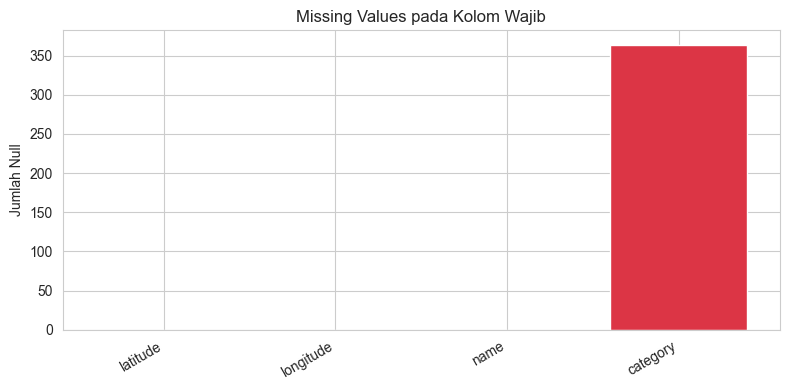


Sampel 10 baris pertama:


,id,name,rating,review,price_level,category,services,address,open_hours,phone,latitude,longitude,url,cluster,source_category,source_file,source_table
0,96,Pacific food court,4.4,233,2,Restaurant,"['Dine-in', 'Takeaway']","5222+C65, Jodoh River, Batu Ampar, Batam City,...",[],,1.151015,104.000602,https://www.google.com/maps/place/Pacific+food...,2.0,F&B,Indonesia.Batam.Kuliner.202406162232.db,places
1,193,Berjaya Masakan Padang,4.0,3,0,Padang restaurant,"['Dine-in', 'Takeaway']","5234+P57, Jodoh River, Batu Ampar, Batam City,...","[{ day: 'Sunday', hours: '09:00 – 21:00' }, { ...",,1.154278,104.005409,https://www.google.com/maps/place/Berjaya+Masa...,0.0,F&B,Indonesia.Batam.Kuliner.202406162232.db,places
2,211,Warung Kopi HARUM,4.4,303,0,Noodle shop,"['Dine-in', 'Takeaway']","5226+2HQ, Jodoh River, Batu Ampar, Batam City,...","[{ day: 'Sunday', hours: '06:00 – 14:00' }, { ...",,1.150087,104.011475,https://www.google.com/maps/place/Warung+Kopi+...,2.0,F&B,Indonesia.Batam.Kuliner.202406162232.db,places
3,230,Toko Barokah,4.0,5,0,Grocery store,['In-store shopping'],"52M7+8FM, Batu Merah, Batu Ampar, Batam City, ...","[{ day: 'Sunday', hours: '07:00 – 21:00' }, { ...",,1.183346,104.013658,https://www.google.com/maps/place/Toko+Barokah...,2.0,F&B,Indonesia.Batam.Kuliner.202406162232.db,places
4,240,Multi Bintang Indonesia,4.5,2,0,Grocery delivery service,[],"5296+42F, Batu Merah, Batu Ampar, Batam City, ...",[],,1.167812,104.010056,https://www.google.com/maps/place/Multi+Bintan...,3.0,F&B,Indonesia.Batam.Kuliner.202406162232.db,places
5,257,Ampera nasi padang Ombak piaman,0.0,0,0,Padang restaurant,"['Dine-in', 'Takeaway']","5243+3P8, Jodoh River, Batu Ampar, Batam City,...","[{ day: 'Sunday', hours: '08:00 – 21:30' }, { ...",,1.155156,104.004325,https://www.google.com/maps/place/Ampera+nasi+...,0.0,F&B,Indonesia.Batam.Kuliner.202406162232.db,places
6,282,Pak Bas Kue & Kripic,4.0,2,0,Food products supplier,[],"52P5+VP2, Batu Merah, Batu Ampar, Batam City, ...","[{ day: 'Sunday', hours: '06:00 – 22:00' }, { ...",+62 812-7742-6621,1.187141,104.009264,https://www.google.com/maps/place/Pak+Bas+Kue+...,2.0,F&B,Indonesia.Batam.Kuliner.202406162232.db,places
7,292,Seblak Teh Senny - Bengkong,3.4,28,0,Buffet restaurant,"['Dine-in', 'Takeaway', 'Delivery']","Pertokoan Jl. Ruko Golden City Blok F No. 6, B...","[{ day: 'Sunday', hours: '03:00 – 23:00' }, { ...",+62 821-7132-0270,1.165564,104.039307,https://www.google.com/maps/place/Seblak+Teh+S...,2.0,F&B,Indonesia.Batam.Kuliner.202406162232.db,places
8,299,SOTO LAMONGAN CAK ALI,4.4,13,0,Soto ayam restaurant,"['Dine-in', 'Takeaway']","Komplek Maritim Square Jodoh, Blk. I No.21, RT...","[{ day: 'Sunday', hours: '11:00 – 21:00' }, { ...",,1.153548,104.005480,https://www.google.com/maps/place/SOTO+LAMONGA...,-1.0,F&B,Indonesia.Batam.Kuliner.202406162232.db,places
9,303,Bina Nusa Mandiri PT,0.0,0,0,Caterer,[],"Bukit Senyum, Batu Ampar, Komplek Malindo Cipt...",[],,1.168829,104.011295,https://www.google.com/maps/place/Bina+Nusa+Ma...,5.0,F&B,Indonesia.Batam.Kuliner.202406162232.db,places


In [25]:
# ── 4.1 Load Data untuk Validasi ────────────────────
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt

print(f"Data berhasil dimuat: {df_raw.shape[0]:,} baris × {df_raw.shape[1]} kolom")

df_dtypes = df_raw.dtypes.reset_index()
df_dtypes.columns = ["kolom", "tipe_data"]
print("\nRingkasan tipe data:")
display(df_dtypes)

required_cols_view = REQUIRED_COLS_FINAL if "REQUIRED_COLS_FINAL" in globals() else REQUIRED_COLS
missing_required = [c for c in required_cols_view if c not in df_raw.columns]
if missing_required:
    print(f"⚠ Kolom wajib hilang: {missing_required}")

null_counts = df_raw[required_cols_view].isnull().sum().reset_index()
null_counts.columns = ["kolom", "jumlah_null"]
null_counts["persentase"] = (null_counts["jumlah_null"] / len(df_raw) * 100).round(2)
print("\nMissing values pada kolom wajib:")
display(null_counts)

plt.figure(figsize=(8, 4))
plt.bar(null_counts["kolom"], null_counts["jumlah_null"], color="#dc3545")
plt.title("Missing Values pada Kolom Wajib")
plt.ylabel("Jumlah Null")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print("\nSampel 10 baris pertama:")
display(df_raw.head(10))

✓ Konversi tipe data selesai

Validation Gate — Detail per Aturan


,aturan,kolom,dibuang,sisa,dibuang_%
0,1 — Null pada kolom wajib,"latitude, longitude, name, category",364,4206,7.96
1,2 — Duplikat dalam file yang sama,"name, latitude, longitude, source_file",0,4206,0.00
2,3 — Duplikat lintas file (cross-file),"name, latitude, longitude",0,4206,0.00
3,4 — Rating di luar rentang 0–5,rating,0,4206,0.00
4,5 — Koordinat di Luar Riau Islands (safety-net),"latitude, longitude",358,3848,7.83
5,6 — Zona koordinat Singapore,"latitude, longitude",34,3814,0.74



Data Quality Report


,keterangan,nilai
0,Total data masuk,4570
1,Total ditolak,756
2,Total valid,3814
3,Tingkat validitas,83.5
4,Rejection log,content/runs\Indonesia.Batam.Kuliner.202406162...



Distribusi Data Valid per Kategori (Top 10)


,category,valid_rows
0,Restaurant,1199
1,Indonesian restaurant,225
2,Padang restaurant,161
3,Seafood restaurant,138
4,Bakso restaurant,137
5,Diner,127
6,Noodle shop,103
7,Chicken restaurant,90
8,Coffee shop,88
9,Cafe,87


Distribusi penuh disimpan: content/runs\Indonesia.Batam.Kuliner.202406162232\data\category_distribution_valid.json


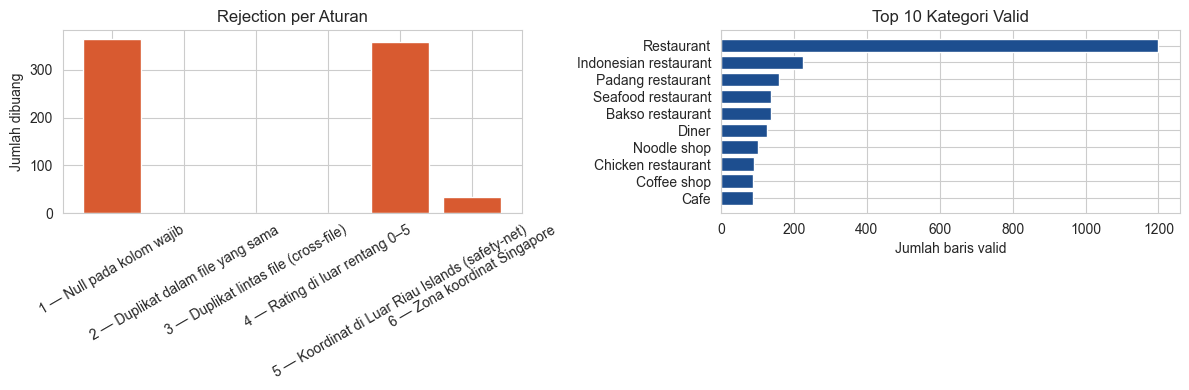


Rejection Reason Summary


,rejection_reason,count
0,null_required_column,364
1,out_of_batam_bounds,358
2,singapore_zone_coordinate,34



───────────────────────────────────────────────────────
  null_required_column  (364 baris)
───────────────────────────────────────────────────────


,name,latitude,longitude,category,rejection_reason
0,Misjid Al Fajri Karas,0.752946,104.320487,NaN,null_required_column
1,Berempah Batam,1.148281,104.013191,NaN,null_required_column
2,Kedai Pak De Seraya,1.150062,104.017006,NaN,null_required_column
3,Kampung Seraya,1.153290,104.024840,NaN,null_required_column
4,Saiful Kuliner,1.018826,104.073730,NaN,null_required_column
5,Pusat Kuliner Jasinta,1.069262,104.124059,NaN,null_required_column
6,Zahra Kuliner,1.019269,104.073465,NaN,null_required_column
7,RedDoorz Hokkie Hotel Punggur Batam,1.062833,104.118471,NaN,null_required_column
8,Hokkie Hotel - Batam Kabil Punggur,1.063247,104.122324,NaN,null_required_column
9,Warung elis,1.029714,103.946305,NaN,null_required_column



───────────────────────────────────────────────────────
  out_of_batam_bounds  (358 baris)
───────────────────────────────────────────────────────


,name,latitude,longitude,category,rejection_reason
0,kulineran kita,0.513791,101.441176,Food and beverage consultant,out_of_batam_bounds
1,bakso ikan Annisa,1.701215,106.221127,Frozen food manufacturer,out_of_batam_bounds
2,Login cafe,-2.445650,117.888800,Meal delivery,out_of_batam_bounds
3,Warteg Citramas,-6.272119,106.527961,Tegal restaurant,out_of_batam_bounds
4,Beef Boss Puri Indah Mall,-6.188796,106.734202,Restaurant,out_of_batam_bounds
5,Hay Thien,-6.185023,106.752386,Hot pot restaurant,out_of_batam_bounds
6,Food Court Puri Indah Mall,-6.188876,106.733707,Food court,out_of_batam_bounds
7,Soto Mie Puri H Darjo (Soto Mie Puri Pak H D...,-6.179502,106.749002,Soto restaurant,out_of_batam_bounds
8,Sate Khas Senayan Puri Indah Mall,-6.187069,106.734280,Indonesian restaurant,out_of_batam_bounds
9,Din Tai Fung - Puri Indah Mall,-6.188489,106.734360,Chinese restaurant,out_of_batam_bounds



───────────────────────────────────────────────────────
  singapore_zone_coordinate  (34 baris)
───────────────────────────────────────────────────────


,name,latitude,longitude,category,rejection_reason
0,Golden Land Restaurant 金土地饺子馆,1.282099,103.842192,Diner,singapore_zone_coordinate
1,Newton Food Centre,1.311989,103.839574,Food court,singapore_zone_coordinate
2,Hong Lim Market & Food Centre,1.285395,103.845827,Hawker center,singapore_zone_coordinate
3,Seletar Sheng Mian Mee Hoon Kway (sims ave),1.317054,103.879329,Hawker Stall,singapore_zone_coordinate
4,Makan Makan,1.291206,103.857677,Indonesian restaurant,singapore_zone_coordinate
5,BHC Chicken Singapore Marina Square,1.292307,103.858255,Chicken restaurant,singapore_zone_coordinate
6,Bebek Goreng Pak Ndut Lucky Plaza,1.304576,103.834034,Indonesian restaurant,singapore_zone_coordinate
7,Kale by KangSu Midpoint Orchard,1.301714,103.838722,Vegetarian restaurant,singapore_zone_coordinate
8,Food Republic 313 somerset,1.301252,103.838552,Food court,singapore_zone_coordinate
9,Riverside Indonesian BBQ,1.300532,103.845236,Coffee shop,singapore_zone_coordinate


In [26]:
# ── 4.2 Validation Gate (Aturan 1-6) ───────────────
import os
import matplotlib.pyplot as plt
from IPython.display import display

df            = df_raw.copy()
total_raw     = len(df)
rejection_log = []
validation_summary = []

# ─────────────────────────────────────────────────────────────────────
# PRE-STEP: Konversi tipe data kolom numerik
# ─────────────────────────────────────────────────────────────────────
# Kolom lat/lon/rating bisa tersimpan sebagai string di SQLite.
# Konversi ke numeric dulu — nilai yang tidak bisa dikonversi
# akan menjadi NaN dan tertangkap oleh Aturan 1 (null check).

numeric_cols = [LAT_COL, LON_COL]
if 'rating' in df.columns:
    numeric_cols.append('rating')

for col in numeric_cols:
    if col in df.columns:
        before = df[col].dtype
        df[col] = pd.to_numeric(df[col], errors='coerce')
        after   = df[col].dtype
        if str(before) != str(after):
            print(f"  konversi kolom '{col}': {before} → {after}")

print("✓ Konversi tipe data selesai\n")

# ─────────────────────────────────────────────────────────────────────
# Aturan 1: Kolom wajib tidak boleh null
# ─────────────────────────────────────────────────────────────────────
missing_cols = [c for c in REQUIRED_COLS if c not in df.columns]
if missing_cols:
    raise ValueError(
        f"Kolom wajib tidak ditemukan di df_raw: {missing_cols}\n"
        f"Periksa COLUMN_MAPPING di Cell 4 atau REQUIRED_COLS di Tahap 2."
    )

mask_null = df[REQUIRED_COLS].isnull().any(axis=1)
null_rows = df[mask_null].copy()
null_rows['rejection_reason'] = 'null_required_column'
rejection_log.append(null_rows)
df = df[~mask_null]

validation_summary.append({
    "aturan"  : "1 — Null pada kolom wajib",
    "kolom"   : ", ".join(REQUIRED_COLS),
    "dibuang" : int(mask_null.sum()),
    "sisa"    : len(df),
})

# ─────────────────────────────────────────────────────────────────────
# Aturan 2: Duplikat dalam file yang sama
# ─────────────────────────────────────────────────────────────────────
df['_lat_r'] = df[LAT_COL].round(5)
df['_lon_r'] = df[LON_COL].round(5)

mask_dup = df.duplicated(
    subset=['name', '_lat_r', '_lon_r', 'source_file'],
    keep='first'
 )
dup_rows = df[mask_dup].copy()
dup_rows['rejection_reason'] = 'duplicate_within_file'
rejection_log.append(dup_rows)
df = df[~mask_dup]

validation_summary.append({
    "aturan"  : "2 — Duplikat dalam file yang sama",
    "kolom"   : "name, latitude, longitude, source_file",
    "dibuang" : int(mask_dup.sum()),
    "sisa"    : len(df),
})

# ─────────────────────────────────────────────────────────────────────
# Aturan 3: Duplikat lintas file (cross-file duplicate)
# ─────────────────────────────────────────────────────────────────────
mask_cross = df.duplicated(
    subset=['name', '_lat_r', '_lon_r'],
    keep='first'
 )
cross_rows = df[mask_cross].copy()
cross_rows['rejection_reason'] = 'duplicate_cross_file'
rejection_log.append(cross_rows)
df = df[~mask_cross]

validation_summary.append({
    "aturan"  : "3 — Duplikat lintas file (cross-file)",
    "kolom"   : "name, latitude, longitude",
    "dibuang" : int(mask_cross.sum()),
    "sisa"    : len(df),
})

df = df.drop(columns=['_lat_r', '_lon_r'])

# ─────────────────────────────────────────────────────────────────────
# Aturan 4: Rating harus dalam rentang wajar (0.0 – 5.0)
# ─────────────────────────────────────────────────────────────────────
if 'rating' in df.columns:
    mask_rating = (
        df['rating'].notna() &
        ~df['rating'].between(0.0, 5.0, inclusive='both')
    )
    rat_rows = df[mask_rating].copy()
    rat_rows['rejection_reason'] = 'rating_out_of_range'
    rejection_log.append(rat_rows)
    df = df[~mask_rating]

    validation_summary.append({
        "aturan"  : "4 — Rating di luar rentang 0–5",
        "kolom"   : "rating",
        "dibuang" : int(mask_rating.sum()),
        "sisa"    : len(df),
    })

# ─────────────────────────────────────────────────────────────────────
# Aturan 5: Koordinat jelas bukan wilayah Batam/Riau Islands
# Hanya menangkap data yang jaraknya sangat jauh (bukan SG/MY yang dekat).
# Filter teks untuk SG/Malaysia ditangani di Aturan 6.

mask_out_batam = (
    (df[LAT_COL] < 0.35) | (df[LAT_COL] > 1.35) |
    (df[LON_COL] < 103.40) | (df[LON_COL] > 104.65)
)
out_rows = df[mask_out_batam].copy()
out_rows['rejection_reason'] = 'out_of_batam_bounds'
rejection_log.append(out_rows)
df = df[~mask_out_batam]

validation_summary.append({
    "aturan"  : "5 — Koordinat di Luar Riau Islands (safety-net)",
    "kolom"   : "latitude, longitude",
    "dibuang" : int(mask_out_batam.sum()),
    "sisa"    : len(df),
})

# ─────────────────────────────────────────────────────────────────────
# Aturan 6: Zona koordinat Singapore (dekat Batam, perlu filter eksplisit)
# Singapore: lat 1.22-1.47 N, lon 103.62-104.01 E
# Masih lolos Rule 5 karena dalam broad box, tapi jelas bukan Batam.
# ─────────────────────────────────────────────────────────────────────
mask_sg_coord = (
    (df[LAT_COL] > 1.20) & (df[LON_COL] < 104.10)
)
sg_coord_rows = df[mask_sg_coord].copy()
sg_coord_rows['rejection_reason'] = 'singapore_zone_coordinate'
rejection_log.append(sg_coord_rows)
df = df[~mask_sg_coord]

validation_summary.append({
    "aturan"  : "6 — Zona koordinat Singapore",
    "kolom"   : "latitude, longitude",
    "dibuang" : int(mask_sg_coord.sum()),
    "sisa"    : len(df),
})

# ─────────────────────────────────────────────────────────────────────
# Simpan rejection log
# ─────────────────────────────────────────────────────────────────────
valid_logs     = [r for r in rejection_log if len(r) > 0]
total_rejected = total_raw - len(df)

if valid_logs:
    df_rejected = pd.concat(valid_logs, ignore_index=True)
    df_rejected.to_csv(f"{OUTPUT_DIR}/rejected_rows.csv", index=False)
else:
    df_rejected = pd.DataFrame()

df = df.reset_index(drop=True)

# ─────────────────────────────────────────────────────────────────────
# Output terstruktur
# ─────────────────────────────────────────────────────────────────────
# Tabel 1: detail per aturan
df_val = pd.DataFrame(validation_summary)
df_val["dibuang_%"] = (df_val["dibuang"] / total_raw * 100).round(2)
print("Validation Gate — Detail per Aturan")
display(df_val)

# Tabel 2: ringkasan akhir
df_summary = pd.DataFrame([
    {"keterangan": "Total data masuk",  "nilai": total_raw},
    {"keterangan": "Total ditolak",     "nilai": total_rejected},
    {"keterangan": "Total valid",       "nilai": len(df)},
    {"keterangan": "Tingkat validitas", "nilai": round(len(df)/total_raw*100, 1)},
    {"keterangan": "Rejection log",     "nilai": f"{OUTPUT_DIR}/rejected_rows.csv"},
])
print("\nData Quality Report")
display(df_summary)

# Tabel 3: distribusi valid per kategori
df_cat_valid = (
    df.groupby(CAT_COL)
    .size()
    .reset_index(name="valid_rows")
    .sort_values("valid_rows", ascending=False)
    .reset_index(drop=True)
 )
print("\nDistribusi Data Valid per Kategori (Top 10)")
display(df_cat_valid.head(10))
if len(df_cat_valid) > 10:
    dist_valid_path = os.path.join(OUTPUT_DIR, "category_distribution_valid.json")
    df_cat_valid.to_json(dist_valid_path, orient="records", force_ascii=True, indent=2)
    print(f"Distribusi penuh disimpan: {dist_valid_path}")

# ── Visualisasi ringkas ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar: jumlah dibuang per aturan
axes[0].bar(df_val["aturan"], df_val["dibuang"], color="#D85A30")
axes[0].set_title("Rejection per Aturan")
axes[0].set_ylabel("Jumlah dibuang")
axes[0].tick_params(axis='x', rotation=30)

# Bar: top kategori valid
top_n = min(10, len(df_cat_valid))
axes[1].barh(df_cat_valid[CAT_COL].head(top_n), df_cat_valid["valid_rows"].head(top_n), color="#1D4E8F")
axes[1].set_title(f"Top {top_n} Kategori Valid")
axes[1].invert_yaxis()
axes[1].set_xlabel("Jumlah baris valid")

plt.tight_layout()
plt.show()

if not df_rejected.empty:
    reject_reason = df_rejected["rejection_reason"].value_counts().reset_index()
    reject_reason.columns = ["rejection_reason", "count"]
    print("\nRejection Reason Summary")
    display(reject_reason)

# ─────────────────────────────────────────────────────────────────────
# Preview per rejection reason
# ─────────────────────────────────────────────────────────────────────
if not df_rejected.empty:
    preview_cols = [c for c in ['name', 'latitude', 'longitude', 'category', 'rejection_reason'] if c in df_rejected.columns]
    for reason, grp in df_rejected.groupby('rejection_reason'):
        count = len(grp)
        print(f"\n{'─'*55}")
        print(f"  {reason}  ({count:,} baris)")
        print(f"{'─'*55}")
        display(grp[preview_cols].head(10).reset_index(drop=True))


---
# Tahap 5 — Preprocessing & Konversi Koordinat

**Ini adalah langkah yang paling sering dilewatkan dan paling kritis.**

DBSCAN di scikit-learn menerima array angka sebagai input. Jika kita langsung masukkan `latitude` dan `longitude` (dalam derajat), maka:
- `eps=0.001` derajat ≈ 111 meter di garis khatulistiwa
- Tapi perbedaan jarak 1 derajat longitude di Batam (lat ~1°N) berbeda dengan di Jakarta (lat ~6°S)

**Solusi:** Konversi ke koordinat UTM Zone 48N (EPSG:32648) yang satuannya **meter** — sehingga `eps=150` benar-benar berarti 150 meter di semua arah, tanpa distorsi.

Alternatif lain adalah menggunakan `metric='haversine'` dengan input radian, tapi pendekatan UTM lebih intuitif untuk tuning parameter.

#### 5.1 Konversi koordinat WGS84 → UTM Zone 48N

Ringkasan rentang koordinat:


,metrik,min,max
0,latitude,0.556898,1.197942
1,longitude,103.418011,104.453762
2,x_utm,323968.260469,439223.420269
3,y_utm,61559.495165,132425.098952



Sampel 10 baris pertama (WGS84 → UTM):


,latitude,longitude,x_utm,y_utm
0,1.151015,104.000602,388808.675066,127241.394226
1,1.154278,104.005409,389343.640633,127601.867659
2,1.150087,104.011475,390018.406080,127138.429168
3,1.183346,104.013658,390262.662658,130815.027225
4,1.167812,104.010056,389861.199647,129097.909087
5,1.155156,104.004325,389223.025219,127699.025668
6,1.187141,104.009264,389773.856398,131234.672603
7,1.165564,104.039307,393115.866044,128848.227864
8,1.153548,104.005480,389351.545948,127521.220667
9,1.168829,104.011295,389999.167856,129210.231633


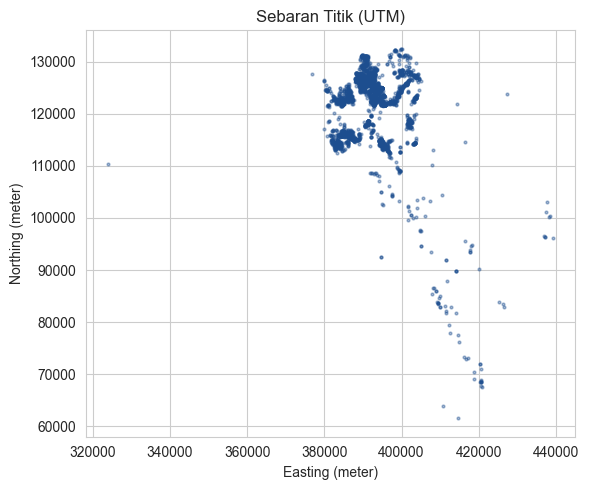

In [27]:
# Mengapa UTM Zone 48N?
# Batam berada di zona UTM 48N (lon 102°E – 108°E, belahan utara).
# Koordinat UTM dalam satuan meter, sehingga EPS_METER langsung berarti meter.
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt

transformer = Transformer.from_crs(CRS_WGS84, CRS_UTM48N, always_xy=True)

# Konversi: lon dulu, baru lat (urutan 'always_xy': x=lon, y=lat)
df['x_utm'], df['y_utm'] = transformer.transform(
    df[LON_COL].values,
    df[LAT_COL].values
)

df_coords = df[[LAT_COL, LON_COL, 'x_utm', 'y_utm']].copy()
summary_ranges = pd.DataFrame([
    {"metrik": "latitude",  "min": df_coords[LAT_COL].min(), "max": df_coords[LAT_COL].max()},
    {"metrik": "longitude", "min": df_coords[LON_COL].min(), "max": df_coords[LON_COL].max()},
    {"metrik": "x_utm",     "min": df_coords['x_utm'].min(),  "max": df_coords['x_utm'].max()},
    {"metrik": "y_utm",     "min": df_coords['y_utm'].min(),  "max": df_coords['y_utm'].max()},
])

print("Ringkasan rentang koordinat:")
display(summary_ranges)

print("\nSampel 10 baris pertama (WGS84 → UTM):")
display(df_coords.head(10))

plt.figure(figsize=(6, 5))
plt.scatter(df['x_utm'], df['y_utm'], s=4, alpha=0.4, color="#1D4E8F")
plt.title("Sebaran Titik (UTM)")
plt.xlabel("Easting (meter)")
plt.ylabel("Northing (meter)")
plt.tight_layout()
plt.show()

### 5.2 Normalisasi fitur rating dan review


Rating — median: 4.40, null diisi median

Ringkasan statistik fitur atribut:


,rating,review_log
count,3814.00,3814.00
mean,3.78,2.28
std,1.70,1.93
min,0.00,0.00
25%,4.00,0.69
50%,4.40,1.79
75%,4.90,3.50
max,5.00,9.09



Top 10 kategori:


,category,count
0,restaurant,1199
1,indonesian restaurant,225
2,padang restaurant,161
3,seafood restaurant,138
4,bakso restaurant,137
5,diner,127
6,noodle shop,103
7,chicken restaurant,90
8,coffee shop,88
9,cafe,87


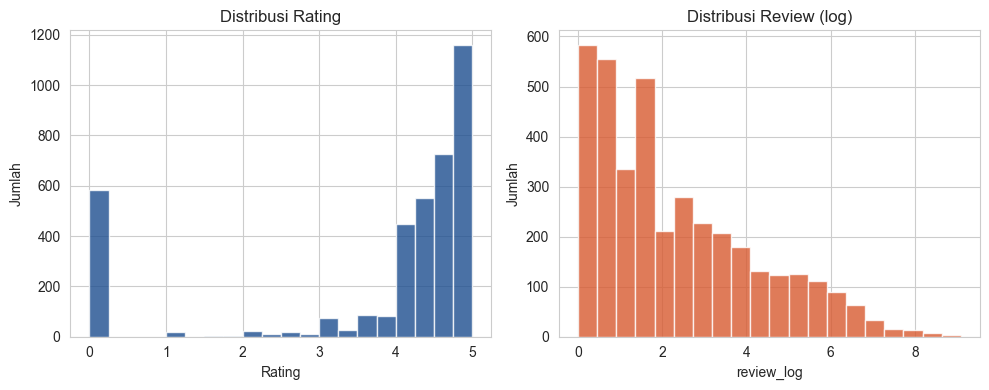


✓ Preprocessing selesai. Shape: (3814, 20)


In [28]:
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt

# --- review_log: transformasi log untuk mengurangi skewness ---
# Usaha dengan 10 review vs 10.000 review tidak perlu dibedakan sebesar itu
if 'reviews' in df.columns:
    df['review_log'] = np.log1p(df['reviews'])  # log(1 + x) agar x=0 tidak error
elif 'review' in df.columns:
    df['review_log'] = np.log1p(df['review'])
else:
    df['review_log'] = 0.0
    print("Kolom review tidak ditemukan, review_log diset 0")

# --- rating: isi nilai null dengan median ---
if 'rating' in df.columns:
    median_rating = df['rating'].median()
    df['rating'] = df['rating'].fillna(median_rating)
    print(f"Rating — median: {median_rating:.2f}, null diisi median")

# --- Normalisasi kategori: lowercase + strip whitespace ---
cat_col = CAT_COL if CAT_COL in df.columns else ("category" if "category" in df.columns else None)
if cat_col:
    df[cat_col] = df[cat_col].astype(str).str.lower().str.strip()
else:
    print("Kolom kategori tidak ditemukan untuk normalisasi")

summary_cols = [c for c in ['rating', 'review_log'] if c in df.columns]
if summary_cols:
    print("\nRingkasan statistik fitur atribut:")
    display(df[summary_cols].describe().round(2))

if cat_col:
    cat_counts = df[cat_col].value_counts().head(10).reset_index()
    cat_counts.columns = [cat_col, 'count']
    print("\nTop 10 kategori:")
    display(cat_counts)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
if 'rating' in df.columns:
    axes[0].hist(df['rating'].dropna(), bins=20, color="#1D4E8F", alpha=0.8)
    axes[0].set_title("Distribusi Rating")
    axes[0].set_xlabel("Rating")
    axes[0].set_ylabel("Jumlah")
else:
    axes[0].axis("off")
    axes[0].text(0.5, 0.5, "Rating tidak tersedia", ha="center", va="center")

if 'review_log' in df.columns:
    axes[1].hist(df['review_log'].dropna(), bins=20, color="#D85A30", alpha=0.8)
    axes[1].set_title("Distribusi Review (log)")
    axes[1].set_xlabel("review_log")
    axes[1].set_ylabel("Jumlah")
else:
    axes[1].axis("off")
    axes[1].text(0.5, 0.5, "Review tidak tersedia", ha="center", va="center")

plt.tight_layout()
plt.show()

print(f"\n✓ Preprocessing selesai. Shape: {df.shape}")

# Tahap 6 — Integrasi Demografi (RBI & Populasi) & OSM

Kita akan load data RBI (untuk masking), Populasi (Kecamatan), dan OSM (Road Network).

### 6.1 Load Data Populasi

In [30]:
import geopandas as gpd
import pandas as pd
import osmnx as ox
import numpy as np
import os
import re
from shapely.geometry import Point

pop_file = "content/data/raw/population_density_2024/statistik-jumlah-penduduk-menurut-jenis-kelamin-dan-kecamatan-di-kota-batam-tahun-2024-semester-1.xlsx"
df_pop = pd.read_excel(pop_file, skiprows=6)
df_pop.columns = ["Unnamed_0", "subdistrict", "female_population", "male_population"]
df_pop = df_pop.dropna(subset=["subdistrict"]).copy()
df_pop = df_pop[~df_pop["subdistrict"].astype(str).str.contains("Jumlah|Kecamatan", case=False, na=False)]
df_pop = df_pop[~df_pop["female_population"].astype(str).str.contains("Penduduk", case=False, na=False)]

def clean_num(x):
    if pd.isna(x):
        return 0
    if isinstance(x, str):
        val = re.sub(r"[^\d]", "", x)
        return int(val) if val else 0
    return int(x * 1000) if x < 1000 else int(x)

df_pop["female_population"] = df_pop["female_population"].apply(clean_num)
df_pop["male_population"] = df_pop["male_population"].apply(clean_num)
df_pop["total_population"] = df_pop["female_population"] + df_pop["male_population"]
df_pop["subdistrict_key"] = df_pop["subdistrict"].astype(str).str.upper().str.replace(" ", "", regex=False)

print("Batam population sample:")
display(df_pop[["subdistrict", "total_population"]])


Batam population sample:


,subdistrict,total_population
2,Belakang Padang,21317
3,Bulang,12426
4,Galang,20251
5,Sungai Beduk,101013
6,Nongsa,99478
7,Sekupang,180779
8,Lubuk Baja,91171
9,Batu Ampar,62678
10,Batam Kota,204577
11,Batu Aji,145536


### 6.2 Load RBI Shapefiles

In [31]:
rbi_dir = "content/data/raw/shapfile_RBI_Kepri_Batam"
kec_shp = os.path.join(rbi_dir, "ADMINISTRASIKECAMATAN_AR_50K.shp")
gdf_subdistrict = gpd.read_file(kec_shp)
gdf_subdistrict["subdistrict_key"] = gdf_subdistrict["NAMOBJ"].astype(str).str.upper().str.replace(" ", "", regex=False)
gdf_subdistrict["subdistrict_key"] = gdf_subdistrict["subdistrict_key"].replace({"SUNGAIBEDUG": "SUNGAIBEDUK"})
gdf_subdistrict = gdf_subdistrict.dissolve(by="subdistrict_key").reset_index()
gdf_subdistrict = gdf_subdistrict.merge(df_pop, on="subdistrict_key", how="inner")

gdf_subdistrict_utm = gdf_subdistrict.to_crs(epsg=32648)
gdf_subdistrict["area_km2"] = gdf_subdistrict_utm.geometry.area / 1e6
gdf_subdistrict["population_density"] = gdf_subdistrict["total_population"] / gdf_subdistrict["area_km2"]
gdf_kec = gdf_subdistrict

print("Subdistrict + population density:")
display(gdf_subdistrict[["NAMOBJ", "area_km2", "total_population", "population_density"]])


Subdistrict + population density:


,NAMOBJ,area_km2,total_population,population_density
0,BATAMKOTA,38.803780,204577,5272.089527
1,BATUAJI,40.356724,145536,3606.239218
2,BATUAMPAR,10.915558,62678,5742.079344
3,BELAKANGPADANG,69.732066,21317,305.698671
4,BENGKONG,13.521980,130176,9626.992192
5,BULANG,158.818132,12426,78.240437
6,GALANG,196.939480,20251,102.828544
7,LUBUKBAJA,11.122848,91171,8196.731492
8,NONGSA,113.179850,99478,878.937375
9,SAGULUNG,51.300465,225144,4388.732137


### 6.3 Build Exclusion Mask (Water + Forests)

In [32]:
water_shps = ["DANAU_AR_50K.shp", "SUNGAI_AR_50K.shp", "RAWA_AR_50K.shp"]
green_shps = ["NONAGRIHUTANBASAH_AR_50K.shp", "NONAGRIHUTANKERING_AR_50K.shp", "NONAGRISEMAKBELUKAR_AR_50K.shp"]

def read_existing_layers(names):
    layers = []
    for shp in names:
        path = os.path.join(rbi_dir, shp)
        if os.path.exists(path):
            layers.append(gpd.read_file(path).to_crs(epsg=4326))
    return layers

water_layers = read_existing_layers(water_shps)
green_layers = read_existing_layers(green_shps)
exclude_layers = water_layers + green_layers
batam_boundary = gdf_subdistrict.geometry.unary_union

if exclude_layers:
    gdf_exclude = pd.concat(exclude_layers, ignore_index=True)
    exclude_union = gdf_exclude.geometry.unary_union
    valid_land_polygon = batam_boundary.difference(exclude_union)
else:
    gdf_exclude = gpd.GeoDataFrame(geometry=[], crs="EPSG:4326")
    exclude_union = None
    valid_land_polygon = batam_boundary

water_union = pd.concat(water_layers, ignore_index=True).geometry.unary_union if water_layers else None
green_union = pd.concat(green_layers, ignore_index=True).geometry.unary_union if green_layers else None

print("RBI valid land mask prepared.")


RBI valid land mask prepared.


### 6.4 Fetch OSM Road Network (Batam)

In [33]:
from scipy.spatial import cKDTree

print("Downloading OSM road network...")
try:
    G = ox.graph_from_polygon(batam_boundary, network_type="drive")
    nodes_proj = ox.project_graph(G, to_crs="EPSG:32648")
    nodes_df, edges_df = ox.graph_to_gdfs(nodes_proj)
    road_coords = np.array([(geom.x, geom.y) for geom in nodes_df.geometry])
    road_tree = cKDTree(road_coords)
    road_edges_utm = edges_df.to_crs(epsg=32648)
    print("OSM road network ready.")
except Exception as exc:
    print(f"Warning: OSM road download failed: {exc}")
    road_coords = np.empty((0, 2))
    road_tree = None
    road_edges_utm = gpd.GeoDataFrame(geometry=[], crs="EPSG:32648")


OSM road network ready.


### 6.5 Pre-compute Base Candidate Grid

In [34]:
from sklearn.neighbors import BallTree

x_min, x_max = 344000, 411000
y_min, y_max = 110000, 144000
step_m = 250

x_grid = np.arange(x_min, x_max, step_m)
y_grid = np.arange(y_min, y_max, step_m)
xx, yy = np.meshgrid(x_grid, y_grid)
grid_pts = np.vstack([xx.ravel(), yy.ravel()]).T

print(f"Initial grid points: {len(grid_pts):,}")
grid_utm_gdf = gpd.GeoDataFrame(geometry=[Point(x, y) for x, y in grid_pts], crs="EPSG:32648")
grid_gdf = grid_utm_gdf.to_crs("EPSG:4326")
grid_gdf["is_valid_land"] = grid_gdf.geometry.intersects(valid_land_polygon).astype(int)
grid_gdf = grid_gdf[grid_gdf["is_valid_land"] == 1].copy()
print(f"Grid points after valid-land mask: {len(grid_gdf):,}")

grid_gdf = gpd.sjoin(
    grid_gdf,
    gdf_subdistrict[["NAMOBJ", "population_density", "geometry"]],
    how="left",
    predicate="intersects",
)

grid_utm = grid_gdf.to_crs("EPSG:32648")
grid_coords = np.array([(geom.x, geom.y) for geom in grid_utm.geometry])

if road_tree is not None and len(grid_coords):
    nearest_road_distance_m, _ = road_tree.query(grid_coords)
else:
    nearest_road_distance_m = np.zeros(len(grid_coords))

if len(road_edges_utm) and len(grid_coords):
    road_centroids = np.array([(geom.centroid.x, geom.centroid.y) for geom in road_edges_utm.geometry])
    road_edge_tree = BallTree(road_centroids, metric="euclidean")
    road_density_500m = road_edge_tree.query_radius(grid_coords, r=500, count_only=True).astype(float)
else:
    road_density_500m = np.zeros(len(grid_coords))

if road_tree is not None and len(grid_coords):
    intersection_density_500m = np.array([len(road_tree.query_ball_point(pt, 500)) for pt in grid_coords], dtype=float)
else:
    intersection_density_500m = np.zeros(len(grid_coords))

road_dist_norm = pd.Series(nearest_road_distance_m)
road_dist_score = 1 - ((road_dist_norm - road_dist_norm.min()) / (road_dist_norm.max() - road_dist_norm.min())) if road_dist_norm.max() > road_dist_norm.min() else pd.Series(np.ones(len(road_dist_norm)))
road_density_norm = pd.Series(road_density_500m)
road_density_norm = (road_density_norm - road_density_norm.min()) / (road_density_norm.max() - road_density_norm.min()) if road_density_norm.max() > road_density_norm.min() else pd.Series(np.zeros(len(road_density_norm)))
road_access_score = (0.7 * road_dist_score + 0.3 * road_density_norm).clip(0, 1)

def distance_to_union(points_gdf_utm, geom_union):
    if geom_union is None or points_gdf_utm.empty:
        return np.zeros(len(points_gdf_utm))
    union_utm = gpd.GeoSeries([geom_union], crs="EPSG:4326").to_crs("EPSG:32648").iloc[0]
    return points_gdf_utm.geometry.distance(union_utm).values

distance_to_water_body_m = distance_to_union(grid_utm, water_union)
distance_to_forest_or_green_area_m = distance_to_union(grid_utm, green_union)

df_base_grid = pd.DataFrame({
    "x_utm": grid_coords[:, 0],
    "y_utm": grid_coords[:, 1],
    "subdistrict": grid_gdf["NAMOBJ"].fillna("Unknown").values,
    "population_density": grid_gdf["population_density"].fillna(0).values,
    "nearest_road_distance_m": nearest_road_distance_m,
    "road_density_500m": road_density_500m,
    "intersection_density_500m": intersection_density_500m,
    "road_access_score": road_access_score.values,
    "is_valid_land": 1,
    "distance_to_water_body_m": distance_to_water_body_m,
    "distance_to_forest_or_green_area_m": distance_to_forest_or_green_area_m,
    "commercial_land_ratio_500m": 0.0,
    "residential_land_ratio_500m": 0.0,
})

os.makedirs(f"content/runs/{TARGET_DB_KEY}/data", exist_ok=True)
df_base_grid.to_parquet(f"content/runs/{TARGET_DB_KEY}/data/base_candidate_grid.parquet", engine="fastparquet")
print(f"Base candidate grid saved: {len(df_base_grid):,} points.")


Initial grid points: 36,448
Grid points after valid-land mask: 4,329
Base candidate grid saved: 4,329 points.


### 6.6 Assign Demographics & Road Distance to DataFrame

In [35]:
gdf_df = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.longitude, df.latitude), crs="EPSG:4326")
gdf_join = gpd.sjoin(
    gdf_df,
    gdf_subdistrict[["NAMOBJ", "population_density", "geometry"]],
    how="left",
    predicate="intersects",
)

df["subdistrict"] = gdf_join["NAMOBJ"].fillna("Unknown").values
df["population_density"] = gdf_join["population_density"].fillna(0).values

df_coords = df[["x_utm", "y_utm"]].values
if road_tree is not None and len(df_coords):
    dists, _ = road_tree.query(df_coords)
    df["nearest_road_distance_m"] = dists
else:
    df["nearest_road_distance_m"] = 0.0

if len(road_edges_utm) and len(df_coords):
    road_centroids = np.array([(geom.centroid.x, geom.centroid.y) for geom in road_edges_utm.geometry])
    road_edge_tree = BallTree(road_centroids, metric="euclidean")
    df["road_density_500m"] = road_edge_tree.query_radius(df_coords, r=500, count_only=True).astype(float)
else:
    df["road_density_500m"] = 0.0

if road_tree is not None and len(df_coords):
    df["intersection_density_500m"] = [len(road_tree.query_ball_point(pt, 500)) for pt in df_coords]
else:
    df["intersection_density_500m"] = 0.0

road_dist_norm = pd.Series(df["nearest_road_distance_m"])
road_dist_score = 1 - ((road_dist_norm - road_dist_norm.min()) / (road_dist_norm.max() - road_dist_norm.min())) if road_dist_norm.max() > road_dist_norm.min() else pd.Series(np.ones(len(df)), index=df.index)
road_density_norm = pd.Series(df["road_density_500m"])
road_density_norm = (road_density_norm - road_density_norm.min()) / (road_density_norm.max() - road_density_norm.min()) if road_density_norm.max() > road_density_norm.min() else pd.Series(np.zeros(len(df)), index=df.index)
df["road_access_score"] = (0.7 * road_dist_score + 0.3 * road_density_norm).clip(0, 1).values

gdf_df_utm = gdf_df.to_crs("EPSG:32648")
df["is_valid_land"] = gdf_df.geometry.intersects(valid_land_polygon).astype(int).values
df["distance_to_water_body_m"] = distance_to_union(gdf_df_utm, water_union)
df["distance_to_forest_or_green_area_m"] = distance_to_union(gdf_df_utm, green_union)
df["commercial_land_ratio_500m"] = 0.0
df["residential_land_ratio_500m"] = 0.0

print("Administrative, RBI, and OSM accessibility features added.")


Administrative, RBI, and OSM accessibility features added.


---
# Tahap 7 — DBSCAN Clustering

### Cara Kerja DBSCAN

DBSCAN mengklasifikasikan setiap titik menjadi salah satu dari tiga jenis:

| Jenis Titik | Kondisi | `cluster_id` |
|---|---|---|
| **Core point** | Punya ≥ `min_samples` tetangga dalam radius `eps` | angka ≥ 0 |
| **Border point** | Berada dalam radius `eps` core point, tapi tetangganya < `min_samples` | angka ≥ 0 (ikut cluster terdekat) |
| **Noise point** | Tidak masuk kategori keduanya | **-1** |

### Mengapa nilai -1 penting?
Titik berlabel `-1` (noise) adalah usaha yang **berdiri sendiri** — tidak ada usaha lain dalam radius `eps` yang cukup membentuk zona. Dalam konteks GeoMarket AI, ini bisa berarti:
- Lokasi terisolasi yang belum terjamah persaingan → peluang pasar
- Atau memang area yang kurang ramai secara umum

Kita **tidak membuang** titik noise — kita tetap gunakan dengan `cluster_id = -1` sebagai fitur tersendiri.

### Mengapa tidak perlu StandardScaler?
Karena input DBSCAN kita hanya dua kolom dalam satuan yang sama (meter), tidak perlu scaling. Jika kita menambahkan fitur lain (rating, dll) ke dalam input DBSCAN, barulah scaling diperlukan.

[Pre-DBSCAN Guard] ✓ Semua 3,814 titik valid — tidak ada titik non-Batam.
Menjalankan DBSCAN dengan eps=500m, min_samples=10...

Ringkasan DBSCAN:


,metrik,nilai
0,Jumlah cluster,19.0
1,Titik dalam cluster,3442.0
2,Titik noise (-1),372.0
3,Noise ratio (%),9.8



Top 10 cluster terbesar:


,cluster_id,count
0,0,1502
1,7,408
2,2,355
3,4,255
4,1,160
5,9,130
6,5,119
7,15,114
8,3,80
9,12,58


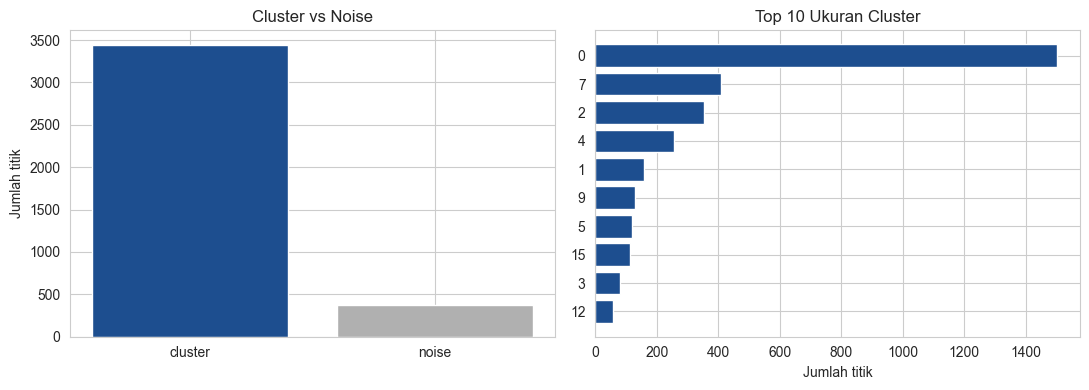

Cluster vs noise disimpan: content/runs\Indonesia.Batam.Kuliner.202406162232\reports\cluster_vs_noise.png


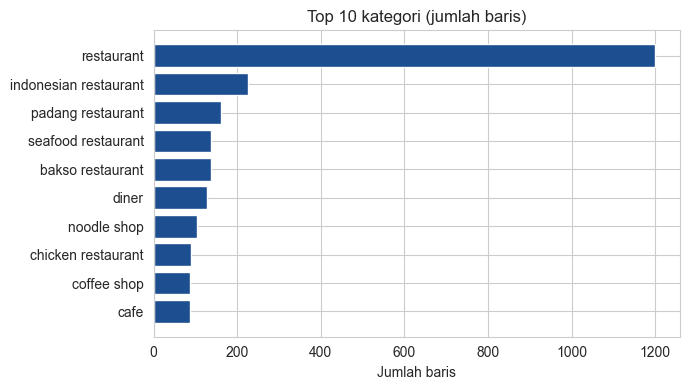

Distribusi kategori (Top 10) disimpan: content/runs\Indonesia.Batam.Kuliner.202406162232\reports/category_distribution_top10.png


In [36]:
# ── 7.0 Pre-DBSCAN Sanitization Guard ────────────────────────────────
# Defensive filter: memastikan tidak ada titik Singapore/Malaysia/luar-Riau
# yang lolos ke DBSCAN, even jika Validation Gate di Tahap 4 dilewati.
# Sama persis dengan Rule 5 + 6 di Validation Gate.
_before = len(df)

# Rule 5: broad box safety-net (bukan Riau Islands)
_mask_far = (
    (df[LAT_COL] < 0.35) | (df[LAT_COL] > 1.35) |
    (df[LON_COL] < 103.40) | (df[LON_COL] > 104.65)
)
df = df[~_mask_far].copy()

# Rule 6a: zona koordinat Singapore (lat > 1.20 AND lon < 104.10)
_mask_sg_coord = (df[LAT_COL] > 1.20) & (df[LON_COL] < 104.10)
df = df[~_mask_sg_coord].copy()

# Rule 6b: kata kunci Singapore/Malaysia di kolom teks
_FOREIGN_KW = r'singapore|singapura|malaysia|kuala.?lumpur|johor|pte\.?\s*ltd'
_mask_kw = pd.Series(False, index=df.index)
for _col in df.columns:
    if df[_col].dtype == object:
        _mask_kw = _mask_kw | df[_col].astype(str).str.contains(
            _FOREIGN_KW, case=False, na=False, regex=True
        )
df = df[~_mask_kw].copy()

_removed = _before - len(df)
if _removed:
    print(f"[Pre-DBSCAN Guard] {_removed} titik non-Batam dihapus dari df sebelum clustering.")
else:
    print(f"[Pre-DBSCAN Guard] ✓ Semua {len(df):,} titik valid — tidak ada titik non-Batam.")

# ── 7.1 Jalankan DBSCAN ──────────────────────────────────────────────
#
# Input: koordinat UTM (x_utm, y_utm) dalam meter
# metric='euclidean' → jarak lurus antar titik dalam meter (akurat karena UTM)
# algorithm='ball_tree' → lebih efisien untuk data geospasial besar
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt

coords_utm = df[['x_utm', 'y_utm']].values

dbscan = DBSCAN(
    eps=EPS_METER,        # radius dalam meter
    min_samples=MIN_SAMPLES,
    metric='euclidean',
    algorithm='ball_tree',
    n_jobs=-1             # gunakan semua CPU core
)

print(f"Menjalankan DBSCAN dengan eps={EPS_METER}m, min_samples={MIN_SAMPLES}...")
df['cluster_id'] = dbscan.fit_predict(coords_utm)

# ── Hasil ringkas ─────────────────────────────────────────────────────
n_clusters  = len(set(df['cluster_id'])) - (1 if -1 in df['cluster_id'].values else 0)
n_noise     = (df['cluster_id'] == -1).sum()
n_clustered = (df['cluster_id'] >= 0).sum()

summary_dbscan = pd.DataFrame([
    {"metrik": "Jumlah cluster", "nilai": n_clusters},
    {"metrik": "Titik dalam cluster", "nilai": n_clustered},
    {"metrik": "Titik noise (-1)", "nilai": n_noise},
    {"metrik": "Noise ratio (%)", "nilai": round(n_noise/len(df)*100, 1)},
])
print("\nRingkasan DBSCAN:")
display(summary_dbscan)

cluster_sizes = df[df['cluster_id'] >= 0]['cluster_id'].value_counts().reset_index()
cluster_sizes.columns = ['cluster_id', 'count']
cluster_sizes = cluster_sizes.sort_values('count', ascending=False)
print("\nTop 10 cluster terbesar:")
display(cluster_sizes.head(10))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(["cluster", "noise"], [n_clustered, n_noise], color=["#1D4E8F", "#B0B0B0"])
axes[0].set_title("Cluster vs Noise")
axes[0].set_ylabel("Jumlah titik")

top_n = min(10, len(cluster_sizes))
axes[1].barh(cluster_sizes['cluster_id'].head(top_n).astype(str), cluster_sizes['count'].head(top_n), color="#1D4E8F")
axes[1].set_title(f"Top {top_n} Ukuran Cluster")
axes[1].invert_yaxis()
axes[1].set_xlabel("Jumlah titik")

plt.tight_layout()
cluster_noise_path = os.path.join(REPORT_DIR, "cluster_vs_noise.png")
plt.savefig(cluster_noise_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Cluster vs noise disimpan: {cluster_noise_path}")

# ── Distribusi kategori (Top 10) ──────────────────────────────────────
if CAT_COL in df.columns:
    cat_counts = df[CAT_COL].value_counts().head(10)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.barh(cat_counts.index.astype(str), cat_counts.values, color="#1D4E8F")
    ax.set_title("Top 10 kategori (jumlah baris)")
    ax.set_xlabel("Jumlah baris")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(f"{REPORT_DIR}/category_distribution_top10.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Distribusi kategori (Top 10) disimpan: {REPORT_DIR}/category_distribution_top10.png")
else:
    print("Kolom kategori tidak ditemukan untuk distribusi Top 10.")

Metrik evaluasi clustering:


,metrik,nilai,target
0,Silhouette Score,0.4231,> 0.3
1,Davies-Bouldin Index,0.4572,< 1.0


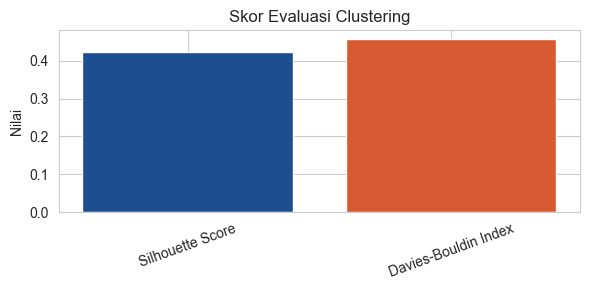

✓ Silhouette Score acceptable (0.4231)


In [37]:
# ── 7.2 Evaluasi Kualitas Clustering ────────────────
#
# Kita gunakan DUA metrik evaluasi clustering yang disebutkan di PRD:
#
# 1. SILHOUETTE SCORE
#    Rentang: -1 hingga +1
#    +1 = cluster sangat terpisah dengan baik
#     0 = titik berada di batas antar cluster
#    -1 = titik salah cluster
#    Target: > 0.3 (acceptable), > 0.5 (good)
#
# 2. DAVIES-BOULDIN INDEX
#    Rentang: 0 hingga tak terhingga
#    Semakin KECIL semakin baik
#    0 = cluster sempurna
#    Target: < 1.0

from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt

df_clustered = df[df['cluster_id'] >= 0]

if len(df_clustered) > 0 and n_clusters >= 2:
    X_eval = df_clustered[['x_utm', 'y_utm']].values
    y_eval = df_clustered['cluster_id'].values

    # Silhouette Score (sample untuk efisiensi jika data besar)
    sample_size = min(5000, len(df_clustered))
    sil_score = silhouette_score(
        X_eval, y_eval,
        sample_size=sample_size,
        random_state=RANDOM_SEED
    )

    # Davies-Bouldin Index
    db_score = davies_bouldin_score(X_eval, y_eval)

    metrics_df = pd.DataFrame([
        {"metrik": "Silhouette Score", "nilai": round(sil_score, 4), "target": "> 0.3"},
        {"metrik": "Davies-Bouldin Index", "nilai": round(db_score, 4), "target": "< 1.0"},
    ])
    print("Metrik evaluasi clustering:")
    display(metrics_df)

    fig, ax = plt.subplots(figsize=(6, 3))
    ax.bar(metrics_df["metrik"], metrics_df["nilai"], color=["#1D4E8F", "#D85A30"])
    ax.set_title("Skor Evaluasi Clustering")
    ax.set_ylabel("Nilai")
    ax.tick_params(axis='x', rotation=20)
    plt.tight_layout()
    plt.show()

    if sil_score < 0.3:
        print("⚠ Silhouette Score di bawah 0.3.")
        print("  → Coba kurangi EPS_METER (cluster terlalu besar/overlap)")
        print("  → Atau kurangi MIN_SAMPLES jika terlalu banyak noise")
    else:
        print(f"✓ Silhouette Score acceptable ({sil_score:.4f})")
else:
    sil_score = None
    db_score  = None
    print("⚠ Tidak cukup cluster untuk menghitung metrik. Coba kecilkan EPS atau MIN_SAMPLES.")

In [38]:
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt

centroids = (
    df[df["cluster_id"] >= 0]
    .groupby("cluster_id")[["x_utm", "y_utm"]]
    .mean()
    .rename(columns={"x_utm": "centroid_x", "y_utm": "centroid_y"})
)
cluster_sizes = df[df["cluster_id"] >= 0].groupby("cluster_id").size().rename("nearest_cluster_size")

df = df.merge(centroids, on="cluster_id", how="left")
df = df.merge(cluster_sizes, on="cluster_id", how="left")
df["cluster_centroid_distance_m"] = np.sqrt(
    (df["x_utm"] - df["centroid_x"])**2 +
    (df["y_utm"] - df["centroid_y"])**2
).fillna(EPS_METER * 2)
df["nearest_cluster_size"] = df["nearest_cluster_size"].fillna(0)
df["is_noise_area"] = (df["cluster_id"] < 0).astype(int)
df = df.drop(columns=["centroid_x", "centroid_y"])

print("Cluster-derived market structure features:")
display(df[["cluster_centroid_distance_m", "nearest_cluster_size", "is_noise_area"]].describe().round(2))


Cluster-derived market structure features:


,cluster_centroid_distance_m,nearest_cluster_size,is_noise_area
count,3814.00,3814.00,3814.0
mean,1359.36,708.55,0.1
std,913.79,650.50,0.3
min,3.16,0.00,0.0
25%,729.09,119.00,0.0
50%,1092.05,408.00,0.0
75%,1737.01,1502.00,0.0
max,5049.76,1502.00,1.0


In [39]:
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import BallTree

coords_for_tree = df[["x_utm", "y_utm"]].values
tree = BallTree(coords_for_tree, metric="euclidean")

for radius in [250, 500, 1000]:
    df[f"business_density_{radius}m"] = tree.query_radius(coords_for_tree, r=radius, count_only=True) - 1

if CAT_COL in df.columns:
    for radius in [250, 500, 1000]:
        df[f"same_category_density_{radius}m"] = 0.0
    df["nearest_same_category_distance_m"] = float(EPS_METER * 2)
    for cat in df[CAT_COL].unique():
        cat_mask = df[CAT_COL] == cat
        cat_coords = df.loc[cat_mask, ["x_utm", "y_utm"]].values
        if len(cat_coords) < 2:
            continue
        cat_tree = BallTree(cat_coords, metric="euclidean")
        for radius in [250, 500, 1000]:
            counts = cat_tree.query_radius(cat_coords, r=radius, count_only=True)
            df.loc[cat_mask, f"same_category_density_{radius}m"] = counts - 1
        d_cat, _ = cat_tree.query(cat_coords, k=2)
        df.loc[cat_mask, "nearest_same_category_distance_m"] = d_cat[:, 1]
else:
    for radius in [250, 500, 1000]:
        df[f"same_category_density_{radius}m"] = 0.0
    df["nearest_same_category_distance_m"] = float(EPS_METER * 2)

dist_nn, _ = tree.query(coords_for_tree, k=2)
df["nearest_business_distance_m"] = dist_nn[:, 1]
area_500_km2 = np.pi * (0.5 ** 2)
df["competitor_saturation_index"] = df["same_category_density_500m"] / area_500_km2

review_source = "reviews" if "reviews" in df.columns else ("review" if "review" in df.columns else None)
df["review_count_log"] = np.log1p(pd.to_numeric(df[review_source], errors="coerce").fillna(0)) if review_source else 0.0
ratings = pd.to_numeric(df["rating"], errors="coerce").fillna(0) if "rating" in df.columns else pd.Series(np.zeros(len(df)))
reviews = pd.Series(df["review_count_log"], index=df.index)
nearby_idx = tree.query_radius(coords_for_tree, r=500)
review_sum, review_mean, rating_mean, diversity = [], [], [], []
for idxs in nearby_idx:
    if not len(idxs):
        review_sum.append(0.0); review_mean.append(0.0); rating_mean.append(0.0); diversity.append(0.0); continue
    review_vals = reviews.iloc[idxs]
    rating_vals = ratings.iloc[idxs]
    cat_counts = df.iloc[idxs][CAT_COL].astype(str).value_counts(normalize=True) if CAT_COL in df.columns else pd.Series(dtype=float)
    entropy = float(-(cat_counts * np.log(cat_counts + 1e-12)).sum()) if len(cat_counts) else 0.0
    review_sum.append(float(review_vals.sum()))
    review_mean.append(float(review_vals.mean()))
    rating_mean.append(float(rating_vals.mean()))
    diversity.append(entropy)

df["nearby_review_count_log_sum_500m"] = review_sum
df["nearby_review_count_log_mean_500m"] = review_mean
df["nearby_avg_rating_500m"] = rating_mean
df["poi_diversity_index"] = diversity

density_cols = [
    "business_density_250m", "business_density_500m", "business_density_1000m",
    "same_category_density_250m", "same_category_density_500m", "same_category_density_1000m",
    "nearest_business_distance_m", "nearest_same_category_distance_m", "competitor_saturation_index",
    "nearby_review_count_log_sum_500m", "nearby_review_count_log_mean_500m", "nearby_avg_rating_500m", "poi_diversity_index",
]
print("Final POI-derived density, competition, and demand features:")
display(df[density_cols].describe().round(2))


Final POI-derived density, competition, and demand features:


,business_density_250m,business_density_500m,business_density_1000m,same_category_density_250m,same_category_density_500m,same_category_density_1000m,nearest_business_distance_m,nearest_same_category_distance_m,competitor_saturation_index,nearby_review_count_log_sum_500m,nearby_review_count_log_mean_500m,nearby_avg_rating_500m,poi_diversity_index
count,3814.00,3814.00,3814.00,3814.00,3814.00,3814.00,3814.00,3814.00,3814.00,3814.00,3814.00,3814.00,3814.00
mean,18.24,47.66,128.12,2.15,5.57,15.05,105.30,1133.19,7.09,117.16,2.29,3.78,2.28
std,17.69,41.68,106.07,4.03,9.53,25.49,967.18,3613.01,12.14,118.22,0.98,0.61,0.70
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.00
25%,5.00,16.00,46.00,0.00,0.00,1.00,14.25,76.63,0.00,31.18,1.55,3.43,1.98
50%,13.00,34.00,109.00,0.00,1.00,4.00,34.10,259.17,1.27,74.71,2.13,3.85,2.44
75%,25.00,71.00,174.00,2.00,6.00,16.00,72.96,855.03,7.64,159.79,2.82,4.19,2.75
max,89.00,197.00,471.00,33.00,60.00,142.00,55639.68,63661.33,76.39,537.22,8.11,5.00,3.37


---
# Tahap 8 — Visualisasi Hasil Clustering

Visualisasi wajib dilakukan sebelum menyimpan output. Tujuannya bukan hanya untuk laporan — tapi untuk **sanity check**: apakah cluster yang terbentuk masuk akal secara geografis?

Hal yang perlu diperiksa:
1. Apakah cluster terbentuk di area yang memang ramai? (Nagoya, Batam Center, Batu Aji)
2. Apakah titik noise (-1) menyebar di area pinggiran?
3. Apakah tidak ada cluster tunggal raksasa yang mencakup seluruh Batam? (jika ya, EPS terlalu besar)

Ringkasan hasil DBSCAN:


,metrik,nilai
0,Jumlah cluster,19.0
1,Titik dalam cluster,3442.0
2,Titik noise,372.0
3,Noise ratio (%),9.8


Statistik ukuran cluster:


,nilai
count,19.00
mean,181.16
std,339.84
min,10.00
25%,35.50
50%,58.00
75%,145.00
max,1502.00


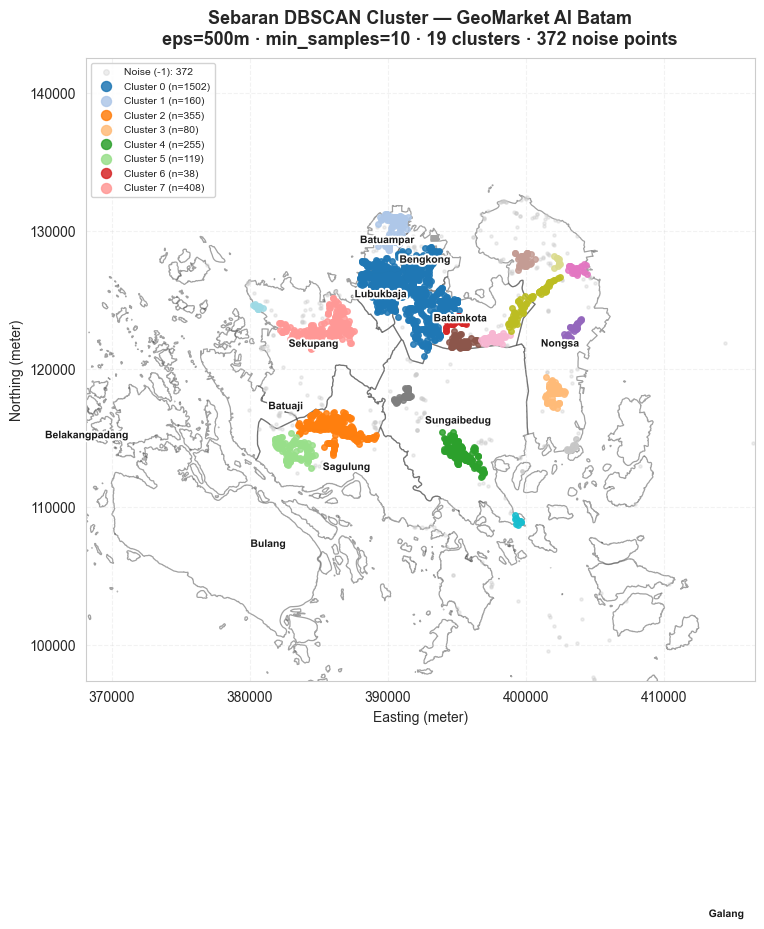

Peta cluster disimpan: content/runs\Indonesia.Batam.Kuliner.202406162232\reports/clustering_map.png


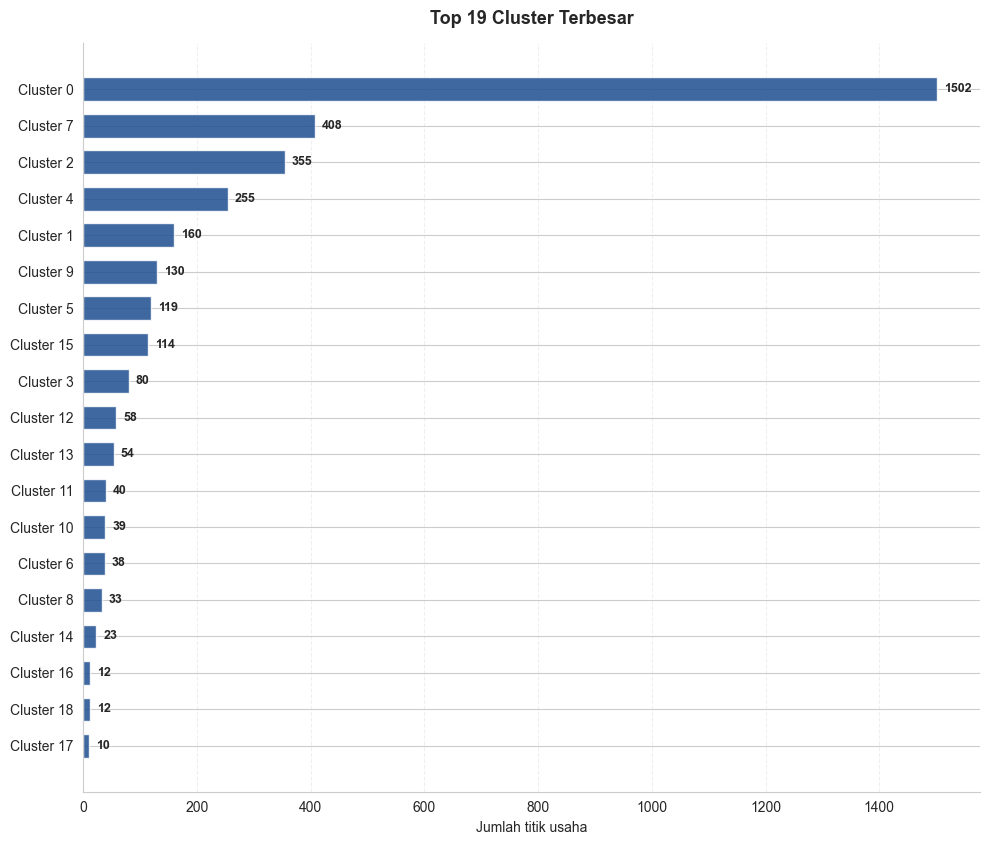

Bar chart disimpan: content/runs\Indonesia.Batam.Kuliner.202406162232\reports/clustering_top_clusters.png


'content/runs\\Indonesia.Batam.Kuliner.202406162232\\reports/clustering_result.png'

In [40]:
# ── 8.1 Peta Sebaran Cluster ──────────────────────
from IPython.display import display
import pandas as pd
import matplotlib.patheffects as pe

summary_vis = pd.DataFrame([
    {"metrik": "Jumlah cluster", "nilai": n_clusters},
    {"metrik": "Titik dalam cluster", "nilai": n_clustered},
    {"metrik": "Titik noise", "nilai": n_noise},
    {"metrik": "Noise ratio (%)", "nilai": round(n_noise / len(df) * 100, 1)},
])
print("Ringkasan hasil DBSCAN:")
display(summary_vis)

cluster_sizes_all = df[df['cluster_id'] >= 0]['cluster_id'].value_counts().sort_values(ascending=False)
cluster_stats = cluster_sizes_all.describe().round(2).to_frame(name="nilai")
print("Statistik ukuran cluster:")
display(cluster_stats)

# ════════════════════════════════════════════════════════
# PLOT 1 — Peta Sebaran Cluster (full-width, zoomed)
# ════════════════════════════════════════════════════════
fig1, ax1 = plt.subplots(figsize=(14, 10))
fig1.suptitle(
    f'Sebaran DBSCAN Cluster — GeoMarket AI Batam\n'
    f'eps={EPS_METER}m · min_samples={MIN_SAMPLES} · '
    f'{n_clusters} clusters · {n_noise} noise points',
    fontsize=13, fontweight='bold'
)

# Overlay subdistrict boundaries + labels
if 'gdf_subdistrict' in dir() or 'gdf_subdistrict' in vars():
    try:
        gdf_sub_utm = gdf_subdistrict.to_crs(epsg=32648)
        gdf_sub_utm.boundary.plot(ax=ax1, color='#444444', linewidth=0.9, alpha=0.5, zorder=0)
        for _, row in gdf_sub_utm.iterrows():
            cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
            label = str(row.get('NAMOBJ', row.get('name', ''))).title()
            ax1.text(
                cx, cy, label,
                fontsize=7.5, ha='center', va='center',
                color='#1a1a1a', fontweight='bold',
                path_effects=[pe.withStroke(linewidth=2.8, foreground='white')],
                zorder=5
            )
    except Exception as e:
        print(f"Subdistrict overlay skipped: {e}")

# Noise points
noise_mask = df['cluster_id'] == -1
ax1.scatter(
    df.loc[noise_mask, 'x_utm'],
    df.loc[noise_mask, 'y_utm'],
    c='#CCCCCC', s=5, alpha=0.35, label=f'Noise (-1): {n_noise:,}', zorder=1
)

# Cluster points
cluster_ids = sorted(df[df['cluster_id'] >= 0]['cluster_id'].unique())
colors = cm.tab20(np.linspace(0, 1, max(len(cluster_ids), 1)))
for i, cid in enumerate(cluster_ids[:20]):
    mask = df['cluster_id'] == cid
    count = mask.sum()
    ax1.scatter(
        df.loc[mask, 'x_utm'],
        df.loc[mask, 'y_utm'],
        c=[colors[i]], s=16, alpha=0.85,
        label=f'Cluster {cid} (n={count})' if i < 8 else None,
        zorder=2
    )

# ── CUSTOM ZOOM PARAMETERS ─────────────────────────────────────────────
# Ubah nilai di bawah ini untuk mengatur tingkat zoom peta!
ZOOM_MODE = "cluster_only"  # Pilih: "cluster_only" (fokus ke cluster) atau "all_data" (lihat semua titik termasuk noise)
PADDING_PERCENT = 0.50      # 0.15 = 15% ruang kosong di pinggir (besarkan jika terlalu nge-zoom)
# ───────────────────────────────────────────────────────────────────────

if ZOOM_MODE == "cluster_only":
    pts = df[df['cluster_id'] >= 0]
    if len(pts) == 0: pts = df  # fallback jika tidak ada cluster
else:
    pts = df

x_min, x_max = pts['x_utm'].min(), pts['x_utm'].max()
y_min, y_max = pts['y_utm'].min(), pts['y_utm'].max()

x_pad = (x_max - x_min) * PADDING_PERCENT
y_pad = (y_max - y_min) * PADDING_PERCENT

ax1.set_xlim(x_min - x_pad, x_max + x_pad)
ax1.set_ylim(y_min - y_pad, y_max + y_pad)

ax1.set_xlabel('Easting (meter)', fontsize=10)
ax1.set_ylabel('Northing (meter)', fontsize=10)
ax1.legend(loc='upper left', fontsize=7.5, ncol=1, markerscale=1.8, framealpha=0.85)
ax1.grid(True, alpha=0.25, linestyle='--')
plt.tight_layout()
scatter_path = f"{REPORT_DIR}/clustering_map.png"
plt.savefig(scatter_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Peta cluster disimpan: {scatter_path}")

# ════════════════════════════════════════════════════════
# PLOT 2 — Top Cluster Bar Chart (full-width)
# ════════════════════════════════════════════════════════
top_n = min(20, len(cluster_sizes_all))
top_clusters = cluster_sizes_all.head(top_n)

fig2, ax2 = plt.subplots(figsize=(10, max(6, top_n * 0.45)))
bars = ax2.barh(
    [f'Cluster {i}' for i in top_clusters.index],
    top_clusters.values,
    color='#1D4E8F', alpha=0.85, edgecolor='white', height=0.65
)
ax2.bar_label(bars, padding=5, fontsize=9, fontweight='bold')
ax2.invert_yaxis()
ax2.set_title(f'Top {top_n} Cluster Terbesar', fontsize=13, fontweight='bold', pad=14)
ax2.set_xlabel('Jumlah titik usaha', fontsize=10)
ax2.grid(True, axis='x', alpha=0.3, linestyle='--')
ax2.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
bar_path = f"{REPORT_DIR}/clustering_top_clusters.png"
plt.savefig(bar_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Bar chart disimpan: {bar_path}")

# Keep legacy combined save path for downstream checks
import shutil
shutil.copy(scatter_path, f"{REPORT_DIR}/clustering_result.png")


---
## 8.2 Tuning Grid DBSCAN (Auto Ranking)

Grid sederhana untuk mencari kombinasi EPS dan min_samples terbaik
berdasarkan Silhouette, Davies-Bouldin, dan noise ratio.

In [41]:
# ── 8.3 Tuning Grid DBSCAN (Auto Ranking) ─────────────
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from IPython.display import display

# Parameter grid (sesuaikan jika perlu)
eps_grid = [80, 100, 120, 150, 180, 200]
min_samples_grid = [4, 5, 6, 8]

results = []
coords = df[['x_utm', 'y_utm']].values

for eps in eps_grid:
    for ms in min_samples_grid:
        model = DBSCAN(eps=eps, min_samples=ms, metric='euclidean', algorithm='ball_tree', n_jobs=-1)
        labels = model.fit_predict(coords)
        n_noise_local = (labels == -1).sum()
        n_clustered_local = (labels >= 0).sum()
        n_clusters_local = len(set(labels)) - (1 if -1 in labels else 0)
        noise_ratio_local = n_noise_local / len(labels) if len(labels) else 1.0

        sil = None
        dbi = None
        if n_clusters_local >= 2 and n_clustered_local > 0:
            X_eval = coords[labels >= 0]
            y_eval = labels[labels >= 0]
            sample_size = min(5000, len(y_eval))
            sil = float(silhouette_score(X_eval, y_eval, sample_size=sample_size, random_state=RANDOM_SEED))
            dbi = float(davies_bouldin_score(X_eval, y_eval))

        results.append({
            "eps": eps,
            "min_samples": ms,
            "n_clusters": n_clusters_local,
            "noise_ratio": round(noise_ratio_local * 100, 2),
            "silhouette": None if sil is None else round(sil, 4),
            "davies_bouldin": None if dbi is None else round(dbi, 4),
        })

df_grid = pd.DataFrame(results)
print("Hasil grid search (ringkas):")
display(df_grid)

# Ranking: prioritaskan silhouette tinggi, DB rendah, noise ratio rendah
df_rank = df_grid.copy()
df_rank['silhouette_rank'] = df_rank['silhouette'].fillna(-1)
df_rank['db_rank'] = df_rank['davies_bouldin'].fillna(9999)
df_rank = df_rank.sort_values(["silhouette_rank", "db_rank", "noise_ratio"], ascending=[False, True, True])
print("\nTop 10 rekomendasi parameter:")
display(df_rank.head(10))

Hasil grid search (ringkas):


,eps,min_samples,n_clusters,noise_ratio,silhouette,davies_bouldin
0,80,4,185,45.07,0.5671,0.3939
1,80,5,120,53.75,0.6127,0.3647
2,80,6,97,58.99,0.6318,0.3406
3,80,8,72,67.80,0.6893,0.3344
4,100,4,186,35.68,0.4883,0.4328
5,100,5,135,43.63,0.5345,0.4282
6,100,6,108,49.84,0.5633,0.3931
7,100,8,72,59.23,0.6543,0.3415
8,120,4,168,29.71,0.4709,0.4432
9,120,5,134,36.08,0.4942,0.4617



Top 10 rekomendasi parameter:


,eps,min_samples,n_clusters,noise_ratio,silhouette,davies_bouldin,silhouette_rank,db_rank
3,80,8,72,67.80,0.6893,0.3344,0.6893,0.3344
11,120,8,74,51.94,0.6586,0.3555,0.6586,0.3555
7,100,8,72,59.23,0.6543,0.3415,0.6543,0.3415
2,80,6,97,58.99,0.6318,0.3406,0.6318,0.3406
1,80,5,120,53.75,0.6127,0.3647,0.6127,0.3647
0,80,4,185,45.07,0.5671,0.3939,0.5671,0.3939
6,100,6,108,49.84,0.5633,0.3931,0.5633,0.3931
10,120,6,109,41.48,0.5562,0.4345,0.5562,0.4345
15,150,8,79,39.88,0.5437,0.4235,0.5437,0.4235
5,100,5,135,43.63,0.5345,0.4282,0.5345,0.4282


---
# Tahap 9 — Simpan ke Feature Store

Feature Store adalah tabel terproses yang menjadi **satu-satunya sumber data** untuk:
- Training Random Forest (Notebook 02)
- Serving API (prediksi real-time)

Dengan memisahkan Feature Store dari raw data, kita memastikan:
- Training dan serving menggunakan fitur yang identik
- Tidak ada kebocoran logika preprocessing antara training dan production
- Jika data baru masuk, cukup jalankan ulang notebook ini

### 9.1 Tentukan kolom yang masuk Feature Store

In [42]:
id_cols = [c for c in ["id", "name", CAT_COL] if c in df.columns]
meta_cols = [c for c in ["source_category", "source_file", "source_table"] if c in df.columns]
coord_cols = [LAT_COL, LON_COL, "x_utm", "y_utm"]

model_feature_cols = [
    "population_density",
    "nearby_review_count_log_sum_500m",
    "nearby_review_count_log_mean_500m",
    "nearby_avg_rating_500m",
    "same_category_density_250m",
    "same_category_density_500m",
    "same_category_density_1000m",
    "nearest_same_category_distance_m",
    "competitor_saturation_index",
    "business_density_250m",
    "business_density_500m",
    "business_density_1000m",
    "nearest_business_distance_m",
    "poi_diversity_index",
    "nearest_road_distance_m",
    "road_density_500m",
    "intersection_density_500m",
    "road_access_score",
    "is_valid_land",
    "distance_to_water_body_m",
    "distance_to_forest_or_green_area_m",
    "commercial_land_ratio_500m",
    "residential_land_ratio_500m",
    "cluster_centroid_distance_m",
    "nearest_cluster_size",
    "is_noise_area",
]

target_support_cols = [c for c in ["rating", "review_count_log", "cluster_id"] if c in df.columns]
feature_cols = id_cols + meta_cols + coord_cols + target_support_cols + model_feature_cols
feature_cols = [c for c in feature_cols if c in df.columns]
feature_cols = list(dict.fromkeys(feature_cols))

df_feature_store = df[feature_cols].copy()

print(f"Feature store columns ({len(feature_cols)} total):")
for col in feature_cols:
    print(f"  {col:<40} {str(df_feature_store[col].dtype):<12} null: {df_feature_store[col].isnull().sum()}")


Feature store columns (39 total):
  id                                       int64        null: 0
  name                                     str          null: 0
  category                                 str          null: 0
  source_category                          str          null: 0
  source_file                              str          null: 0
  source_table                             str          null: 0
  latitude                                 float64      null: 0
  longitude                                float64      null: 0
  x_utm                                    float64      null: 0
  y_utm                                    float64      null: 0
  rating                                   float64      null: 0
  review_count_log                         float64      null: 0
  cluster_id                               int64        null: 0
  population_density                       float64      null: 0
  nearby_review_count_log_sum_500m         float64      null: 0
  near

### 9.2 Simpan Feature Store

In [43]:
df_feature_store.to_csv(FEATURE_STORE_PATH, index=False)
print(f"✓ Feature Store disimpan: {FEATURE_STORE_PATH}")
print(f"  Shape: {df_feature_store.shape}")
print(f"  Ukuran file: {os.path.getsize(FEATURE_STORE_PATH)/1024:.1f} KB")

print(f"\nSampel 3 baris Feature Store:")
df_feature_store.head(3)

✓ Feature Store disimpan: content/runs\Indonesia.Batam.Kuliner.202406162232\data\feature_store.csv
  Shape: (3814, 39)
  Ukuran file: 1691.4 KB

Sampel 3 baris Feature Store:


,id,name,category,source_category,source_file,source_table,latitude,longitude,x_utm,y_utm,...,intersection_density_500m,road_access_score,is_valid_land,distance_to_water_body_m,distance_to_forest_or_green_area_m,commercial_land_ratio_500m,residential_land_ratio_500m,cluster_centroid_distance_m,nearest_cluster_size,is_noise_area
0,96,Pacific food court,restaurant,F&B,Indonesia.Batam.Kuliner.202406162232.db,places,1.151015,104.000602,388808.675066,127241.394226,...,53,0.720810,1,2286.294042,778.562884,0.0,0.0,2789.764362,1502.0,0
1,193,Berjaya Masakan Padang,padang restaurant,F&B,Indonesia.Batam.Kuliner.202406162232.db,places,1.154278,104.005409,389343.640633,127601.867659,...,134,0.768807,1,2540.610938,525.931160,0.0,0.0,2585.152329,1502.0,0
2,211,Warung Kopi HARUM,noodle shop,F&B,Indonesia.Batam.Kuliner.202406162232.db,places,1.150087,104.011475,390018.406080,127138.429168,...,153,0.776618,1,2367.927216,288.315660,0.0,0.0,1783.669211,1502.0,0


### 9.3 Simpan Metadata Clustering

In [45]:
import os
import json
import datetime

FEATURE_SCHEMA_VERSION = "location_regression_v1"

db_file_names = [os.path.basename(p) for p in db_files] if "db_files" in globals() else []
metadata = {
    "notebook": "01_feature_engineering_and_clustering",
    "timestamp": datetime.datetime.now().isoformat(),
    "target_db": TARGET_DB_FILE,
    "db_files": db_file_names,
    "feature_schema_version": FEATURE_SCHEMA_VERSION,
    "paths": {
        "run_dir": RUN_DIR,
        "data_dir": OUTPUT_DIR,
        "report_dir": REPORT_DIR,
        "model_dir": MODEL_DIR,
        "feature_store_path": FEATURE_STORE_PATH,
    },
    "params": {
        "eps_meter": EPS_METER,
        "min_samples": MIN_SAMPLES,
        "category_col": CAT_COL,
        "crs_input": CRS_WGS84,
        "crs_output": CRS_UTM48N,
    },
    "results": {
        "n_clusters": int(n_clusters),
        "n_noise": int(n_noise),
        "n_clustered": int(n_clustered),
        "noise_ratio_pct": round(n_noise / len(df) * 100, 2),
        "silhouette_score": round(sil_score, 4) if sil_score else None,
        "davies_bouldin_idx": round(db_score, 4) if db_score else None,
    },
    "output": {
        "feature_columns": feature_cols,
        "model_feature_columns": model_feature_cols,
    },
}

with open(METADATA_PATH, "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Metadata saved: {METADATA_PATH}")
print(json.dumps(metadata, indent=2))


Metadata saved: content/runs\Indonesia.Batam.Kuliner.202406162232\models\clustering_metadata.json
{
  "notebook": "01_feature_engineering_and_clustering",
  "timestamp": "2026-06-17T10:28:56.837686",
  "target_db": "Indonesia.Batam.Kuliner.202406162232.db",
  "db_files": [
    "Indonesia.Batam.Kuliner.202406162232.db"
  ],
  "feature_schema_version": "location_regression_v1",
  "paths": {
    "run_dir": "content/runs\\Indonesia.Batam.Kuliner.202406162232",
    "data_dir": "content/runs\\Indonesia.Batam.Kuliner.202406162232\\data",
    "report_dir": "content/runs\\Indonesia.Batam.Kuliner.202406162232\\reports",
    "model_dir": "content/runs\\Indonesia.Batam.Kuliner.202406162232\\models",
    "feature_store_path": "content/runs\\Indonesia.Batam.Kuliner.202406162232\\data\\feature_store.csv"
  },
  "params": {
    "eps_meter": 500,
    "min_samples": 10,
    "category_col": "category",
    "crs_input": "EPSG:4326",
    "crs_output": "EPSG:32648"
  },
  "results": {
    "n_clusters": 19,


---
### 9.4 Ringkasan & Langkah Selanjutnya

Yang sudah diselesaikan notebook ini:

| Tahap | Status | Output |
|---|---|---|
| Ingestion dari SQLite | ✓ | DataFrame raw |
| Validation Gate (4 aturan) | ✓ | `rejected_rows.csv` |
| Konversi WGS84 → UTM | ✓ | Kolom `x_utm`, `y_utm` |
| DBSCAN Clustering | ✓ | Kolom `cluster_id` |
| Evaluasi (Silhouette + DB Index) | ✓ | Tercatat di metadata |
| Hitung centroid & jarak | ✓ | Kolom `dist_to_cluster_centroid_m` |
| Hitung fitur density | ✓ | 4 kolom density |
| Simpan Feature Store | ✓ | `feature_store.csv` |
| Simpan Metadata | ✓ | `clustering_metadata.json` |

Sebelum lanjut ke Notebook 02 (Random Forest), pastikan:

1. **Silhouette Score > 0.3** — jika tidak, tuning `EPS_METER` di Tahap 6
2. **Noise ratio < 30%** — jika lebih, kemungkinan `EPS` terlalu kecil atau `MIN_SAMPLES` terlalu besar
3. **Cluster masuk akal geografis** — periksa visualisasi, cluster harus terbentuk di area yang memang ramai (Nagoya Hill, Batam Center, Batu Aji, dll)
4. **Feature Store tidak ada null** — cek kolom `cluster_id` dan `dist_to_cluster_centroid_m`

Panduan tuning cepat:

| Gejala | Solusi |
|---|---|
| Terlalu banyak noise (>40%) | Besarkan `EPS_METER` atau kecilkan `MIN_SAMPLES` |
| Semua jadi satu cluster besar | Kecilkan `EPS_METER` |
| Terlalu banyak cluster kecil | Besarkan `MIN_SAMPLES` |
| Silhouette Score negatif | `EPS` terlalu besar, cluster overlap |

File output:
```
content/
└── runs/
    └── <db_key>/
        ├── data/
        │   ├── feature_store.csv         ← input untuk Notebook 02
        │   └── rejected_rows.csv         ← data yang ditolak Validation Gate
        ├── reports/
        │   └── clustering_result.png     ← visualisasi sebaran cluster
        └── models/
            └── clustering_metadata.json  ← metadata run ini
```

### 9.5 Final Sanity Check

In [46]:
print("="*55)
print("  FINAL CHECK — Notebook 01 DBSCAN Clustering")
print("="*55)

checks = [
    (FEATURE_STORE_PATH, "Feature Store CSV"),
    (METADATA_PATH,      "Clustering Metadata JSON"),
    (f"{OUTPUT_DIR}/rejected_rows.csv",      "Rejected Rows Log"),
    (f"{REPORT_DIR}/clustering_result.png",  "Visualisasi Cluster"),
]

all_ok = True
for path, label in checks:
    exists = os.path.exists(path)
    status = "✓" if exists else "✗"
    if not exists:
        all_ok = False
    size = f"{os.path.getsize(path)/1024:.1f} KB" if exists else "—"
    print(f"  {status} {label:<30} {size}")

print("="*55)
print(f"  Cluster ID range : {df['cluster_id'].min()} s.d. {df['cluster_id'].max()}")
print(f"  Total data       : {len(df_feature_store):,} baris")
if sil_score:
    print(f"  Silhouette Score : {sil_score:.4f}")
    print(f"  Davies-Bouldin   : {db_score:.4f}")
print("="*55)

if all_ok:
    print("\n✓ Semua output tersedia. Lanjut keTahap 10: Random Forest Training.")
else:
    print("\n⚠ Ada output yang belum tersedia. Periksa cell di atas.")

  FINAL CHECK — Notebook 01 DBSCAN Clustering
  ✓ Feature Store CSV              1691.4 KB
  ✓ Clustering Metadata JSON       3.2 KB
  ✓ Rejected Rows Log              422.5 KB
  ✓ Visualisasi Cluster            286.2 KB
  Cluster ID range : -1 s.d. 18
  Total data       : 3,814 baris
  Silhouette Score : 0.4231
  Davies-Bouldin   : 0.4572

✓ Semua output tersedia. Lanjut keTahap 10: Random Forest Training.


---
# Tahap 10 — Quality Gate DBSCAN

Pastikan konfigurasi DBSCAN sudah menghasilkan cluster yang layak sebelum lanjut ke Random Forest.
Gate ini tidak menghentikan proses, tapi memberi peringatan jika kualitas terlalu rendah.

In [47]:
# ── 10.1 Quality Gate DBSCAN ───────────────────────
required_vars = ["n_clusters", "n_noise", "df"]
missing = [v for v in required_vars if v not in globals()]

if missing:
    print(f"⚠ Variabel belum tersedia: {missing}")
    print("Jalankan Tahap 5 terlebih dahulu (DBSCAN).")
else:
    noise_ratio = n_noise / len(df) if len(df) > 0 else 1.0
    print("DBSCAN Quality Gate")
    print("-" * 40)
    print(f"Total data        : {len(df):,}")
    print(f"Jumlah cluster    : {n_clusters}")
    print(f"Noise ratio       : {noise_ratio*100:.1f}%")
    if 'sil_score' in globals() and sil_score is not None:
        print(f"Silhouette Score  : {sil_score:.4f}")
    else:
        print("Silhouette Score  : belum dihitung")

    if noise_ratio > 0.4:
        print("⚠ Noise ratio tinggi (>40%). Pertimbangkan menaikkan EPS_METER atau menurunkan MIN_SAMPLES.")
    if 'sil_score' in globals() and sil_score is not None and sil_score < 0.3:
        print("⚠ Silhouette Score < 0.3. Cluster kemungkinan overlap.")
    print("-" * 40)

DBSCAN Quality Gate
----------------------------------------
Total data        : 3,814
Jumlah cluster    : 19
Noise ratio       : 9.8%
Silhouette Score  : 0.4231
----------------------------------------


---
# Tahap 11 — Random Forest Training (Rekomendasi Lokasi)

Tahap ini membuat label proxy `High/Medium/Low` berdasarkan formula PRD,
lalu melatih model Random Forest dengan spatial split untuk menghindari data leakage.

### 11.1 Load Feature Store & Label Proxy

Ringkas: load feature store, buat hotspot score, dan label proxy.

In [48]:
import os
import numpy as np
import pandas as pd

FEATURE_SCHEMA_VERSION = "location_regression_v1"
# REMOVED_FEATURES = [
#     "hotspot_score", "female_ratio", "has_phone", "has_url", "has_open_hours",
#     "price_level", "nearby_price_level_median_500m", "cluster_id"
# ]

df_fs = pd.read_csv(FEATURE_STORE_PATH)
print(f"Feature store loaded: {df_fs.shape[0]:,} rows x {df_fs.shape[1]} columns")

model_feature_cols = [
    "population_density",
    "nearby_review_count_log_sum_500m",
    "nearby_review_count_log_mean_500m",
    "nearby_avg_rating_500m",
    "same_category_density_250m",
    "same_category_density_500m",
    "same_category_density_1000m",
    "nearest_same_category_distance_m",
    "competitor_saturation_index",
    "business_density_250m",
    "business_density_500m",
    "business_density_1000m",
    "nearest_business_distance_m",
    "poi_diversity_index",
    "nearest_road_distance_m",
    "road_density_500m",
    "intersection_density_500m",
    "road_access_score",
    "is_valid_land",
    "distance_to_water_body_m",
    "distance_to_forest_or_green_area_m",
    "commercial_land_ratio_500m",
    "residential_land_ratio_500m",
    "cluster_centroid_distance_m",
    "nearest_cluster_size",
    "is_noise_area",
]

missing_features = [c for c in model_feature_cols if c not in df_fs.columns]
if missing_features:
    raise ValueError(f"Missing model features: {missing_features}")

for col in model_feature_cols:
    df_fs[col] = pd.to_numeric(df_fs[col], errors="coerce").replace([np.inf, -np.inf], np.nan).fillna(0.0)

rating_norm = pd.to_numeric(df_fs.get("rating", 0.0), errors="coerce").fillna(0.0) / 5.0
review_norm = df_fs["review_count_log"] if "review_count_log" in df_fs.columns else df_fs["nearby_review_count_log_mean_500m"]
review_norm = pd.to_numeric(review_norm, errors="coerce").fillna(0.0)
if review_norm.max() > review_norm.min():
    review_norm = (review_norm - review_norm.min()) / (review_norm.max() - review_norm.min())
else:
    review_norm = pd.Series(np.zeros(len(df_fs)), index=df_fs.index)

df_fs["suitability_score"] = (0.45 * rating_norm + 0.55 * review_norm).clip(0, 1)
q1, q2 = df_fs["suitability_score"].quantile([0.33, 0.66])
df_fs["suitability_band"] = pd.cut(
    df_fs["suitability_score"],
    bins=[-np.inf, q1, q2, np.inf],
    labels=["Low", "Medium", "High"],
)
suitability_band_thresholds = {"low_max": float(q1), "medium_max": float(q2)}

print("Suitability score summary:")
display(df_fs[["suitability_score", "suitability_band"]].describe(include="all"))
print("Band thresholds:", suitability_band_thresholds)


Feature store loaded: 3,814 rows x 39 columns
Suitability score summary:


,suitability_score,suitability_band
count,3814.000000,3814
unique,NaN,3
top,NaN,Low
freq,NaN,1493
mean,0.478414,NaN
std,0.229747,NaN
min,0.000000,NaN
25%,0.468382,NaN
50%,0.522382,NaN
75%,0.610136,NaN


Band thresholds: {'low_max': 0.49192774498013075, 'medium_max': 0.5736338062208768}


### 11.2 Ringkasan Label (Ambang Batas)

Ringkas: tampilkan distribusi label dan ambang kuantil.

In [49]:
# ── 11.2 Tampilkan batas kuantil yang digunakan ────────
if 'q1' not in globals():
    q1, q2 = df_fs["suitability_score"].quantile([0.33, 0.66])

print("=== Ambang Kuantil untuk Label ===")
print(f"Q1 (Batas Bawah Medium) : {q1:.2f}")
print(f"Q2 (Batas Bawah Tinggi) : {q2:.2f}\n")

# Hitung dan tampilkan distribusi label
print("=== Distribusi Label Suitability ===")
distribusi_label = df_fs['suitability_band'].value_counts().reset_index()
distribusi_label.columns = ['Label', 'Jumlah Baris']
distribusi_label['Persentase'] = (distribusi_label['Jumlah Baris'] / len(df_fs) * 100).round(2).astype(str) + '%'
display(distribusi_label)


=== Ambang Kuantil untuk Label ===
Q1 (Batas Bawah Medium) : 0.49
Q2 (Batas Bawah Tinggi) : 0.57

=== Distribusi Label Suitability ===


,Label,Jumlah Baris,Persentase
0,Low,1493,39.15%
1,High,1292,33.88%
2,Medium,1029,26.98%


### 11.3 Negative Sampling
Menambahkan lokasi dummy di area terlarang atau sangat jauh dari jalan sebagai 'Low Suitability' agar RF bisa belajar lokasi buruk.

In [50]:
# 11.3 Negative candidate samples for regression target
if "df_base_grid" in locals() and len(df_base_grid):
    bad_mask = (df_base_grid["nearest_road_distance_m"] > 1000) | (df_base_grid["population_density"] < 10)
    pool = df_base_grid[bad_mask].copy()
    if len(pool) > 0:
        neg_samples = pool.sample(min(1000, len(pool)), replace=len(pool) < 1000, random_state=RANDOM_SEED).copy()
        for col in model_feature_cols:
            if col not in neg_samples.columns:
                neg_samples[col] = 0.0
        neg_samples["nearby_review_count_log_sum_500m"] = 0.0
        neg_samples["nearby_review_count_log_mean_500m"] = 0.0
        neg_samples["nearby_avg_rating_500m"] = 0.0
        neg_samples["same_category_density_250m"] = 0.0
        neg_samples["same_category_density_500m"] = 0.0
        neg_samples["same_category_density_1000m"] = 0.0
        neg_samples["nearest_same_category_distance_m"] = 5000.0
        neg_samples["business_density_250m"] = 0.0
        neg_samples["business_density_500m"] = 0.0
        neg_samples["business_density_1000m"] = 0.0
        neg_samples["nearest_business_distance_m"] = 5000.0
        neg_samples["competitor_saturation_index"] = 0.0
        neg_samples["cluster_centroid_distance_m"] = 5000.0
        neg_samples["nearest_cluster_size"] = 0.0
        neg_samples["is_noise_area"] = 1.0
        neg_samples["suitability_score"] = 0.0
        neg_samples["suitability_band"] = "Low"
        missing_cols = set(df_fs.columns) - set(neg_samples.columns)
        for c in missing_cols:
            neg_samples[c] = np.nan
        df_fs = pd.concat([df_fs, neg_samples[df_fs.columns]], ignore_index=True)
        print(f"Added {len(neg_samples)} negative candidate samples.")
    else:
        print("No negative samples matched the road/population criteria.")
else:
    print("df_base_grid not found; negative sampling skipped.")


Added 489 negative candidate samples.


### 11.4 Ringkasan Distribusi Label Setelah Sampling

In [51]:
from IPython.display import display

if 'q1' not in globals():
    q1, q2 = df_fs["suitability_score"].quantile([0.33, 0.66])

label_counts = df_fs["suitability_band"].value_counts(dropna=False)
label_pct = (label_counts / label_counts.sum() * 100).round(2)
label_summary = pd.DataFrame({"count": label_counts, "pct": label_pct})

thresholds = pd.DataFrame({"q1": [q1], "q2": [q2]})

display(label_summary)
display(thresholds)


,count,pct
suitability_band,,
Low,1982,46.06
High,1292,30.03
Medium,1029,23.91


,q1,q2
0,0.491928,0.573634


### 11.5 Spatial Split & Train Random Forest

Ringkas: split grid 1km untuk hindari leakage lalu training model.

In [52]:
from sklearn.model_selection import GroupShuffleSplit, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import spearmanr
import joblib

try:
    from lightgbm import LGBMRegressor
except Exception as exc:
    LGBMRegressor = None
    print(f"LightGBM unavailable: {exc}")
try:
    from xgboost import XGBRegressor
except Exception as exc:
    XGBRegressor = None
    print(f"XGBoost unavailable: {exc}")

X = df_fs[model_feature_cols].copy()
y = pd.to_numeric(df_fs["suitability_score"], errors="coerce").fillna(0.0)

grid_size_m = 1000
grid_x = (df_fs["x_utm"] // grid_size_m).astype(int)
grid_y = (df_fs["y_utm"] // grid_size_m).astype(int)
df_fs["grid_id"] = grid_x.astype(str) + "_" + grid_y.astype(str)

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_SEED)
train_idx, test_idx = next(gss.split(X, y, groups=df_fs["grid_id"]))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

models = {
    "linear_regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ]),
    "random_forest_regressor": RandomForestRegressor(n_estimators=300, random_state=RANDOM_SEED, n_jobs=-1),
    "extra_trees_regressor": ExtraTreesRegressor(n_estimators=300, random_state=RANDOM_SEED, n_jobs=-1),
}
if LGBMRegressor is not None:
    models["lightgbm_regressor"] = LGBMRegressor(n_estimators=400, learning_rate=0.05, random_state=RANDOM_SEED, n_jobs=-1, verbose=-1)
if XGBRegressor is not None:
    models["xgboost_regressor"] = XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=5, subsample=0.9, colsample_bytree=0.9, random_state=RANDOM_SEED, n_jobs=-1, objective="reg:squarederror")

param_spaces = {
    "random_forest_regressor": {"n_estimators": [200, 300, 500], "max_depth": [None, 8, 16], "min_samples_leaf": [1, 2, 4]},
    "extra_trees_regressor": {"n_estimators": [200, 300, 500], "max_depth": [None, 8, 16], "min_samples_leaf": [1, 2, 4]},
    "lightgbm_regressor": {"num_leaves": [15, 31, 63], "max_depth": [-1, 6, 10], "min_child_samples": [10, 20, 40]},
    "xgboost_regressor": {"max_depth": [3, 5, 7], "subsample": [0.8, 0.9, 1.0], "colsample_bytree": [0.8, 0.9, 1.0]},
}

def precision_at_k(y_true, y_pred, k=20):
    k = min(k, len(y_true))
    if k == 0:
        return 0.0
    true_high_threshold = np.quantile(y_true, 0.66)
    top_idx = np.argsort(y_pred)[::-1][:k]
    return float((np.asarray(y_true)[top_idx] >= true_high_threshold).mean())

def top_k_overlap(y_true, y_pred, k=20):
    k = min(k, len(y_true))
    if k == 0:
        return 0.0
    true_top = set(np.argsort(np.asarray(y_true))[::-1][:k])
    pred_top = set(np.argsort(np.asarray(y_pred))[::-1][:k])
    return len(true_top & pred_top) / k

comparison_rows = []
fitted_models = {}
for name, estimator in models.items():
    print(f"Training {name}...")
    if name in param_spaces:
        search = RandomizedSearchCV(
            estimator,
            param_spaces[name],
            n_iter=min(6, np.prod([len(v) for v in param_spaces[name].values()])),
            scoring="neg_root_mean_squared_error",
            cv=3,
            random_state=RANDOM_SEED,
            n_jobs=-1,
        )
        search.fit(X_train, y_train)
        fitted = search.best_estimator_
        best_params = search.best_params_
    else:
        fitted = estimator.fit(X_train, y_train)
        best_params = {}
    pred = np.clip(fitted.predict(X_test), 0, 1)
    rmse = float(np.sqrt(mean_squared_error(y_test, pred)))
    mae = float(mean_absolute_error(y_test, pred))
    r2 = float(r2_score(y_test, pred))
    spear = float(spearmanr(y_test, pred).correlation) if len(y_test) > 1 else 0.0
    if np.isnan(spear):
        spear = 0.0
    p_at_k = precision_at_k(y_test.values, pred, k=20)
    overlap = top_k_overlap(y_test.values, pred, k=20)
    comparison_rows.append({
        "model": name,
        "mae": mae,
        "rmse": rmse,
        "r2": r2,
        "spearman_rank": spear,
        "precision_at_20": p_at_k,
        "top_20_overlap": overlap,
        "best_params": json.dumps(best_params),
    })
    fitted_models[name] = fitted

model_comparison_df = pd.DataFrame(comparison_rows).sort_values(
    ["spearman_rank", "precision_at_20", "rmse"],
    ascending=[False, False, True],
).reset_index(drop=True)
best_model_name = model_comparison_df.loc[0, "model"]
best_model = fitted_models[best_model_name]
model_comparison_path = os.path.join(REPORT_DIR, "model_comparison.csv")
model_comparison_df.to_csv(model_comparison_path, index=False)

print("Model comparison:")
display(model_comparison_df)
print(f"Best model: {best_model_name}")


Training linear_regression...
Training random_forest_regressor...
Training extra_trees_regressor...
Training lightgbm_regressor...
Training xgboost_regressor...
Model comparison:


,model,mae,rmse,r2,spearman_rank,precision_at_20,top_20_overlap,best_params
0,xgboost_regressor,0.102446,0.153018,0.684537,0.747304,0.90,0.35,"{""subsample"": 0.8, ""max_depth"": 3, ""colsample_..."
1,linear_regression,0.102257,0.151497,0.690781,0.743790,0.95,0.45,{}
2,extra_trees_regressor,0.102512,0.152705,0.685826,0.742430,0.95,0.35,"{""n_estimators"": 300, ""min_samples_leaf"": 2, ""..."
3,random_forest_regressor,0.102556,0.153066,0.684340,0.740023,0.95,0.30,"{""n_estimators"": 500, ""min_samples_leaf"": 1, ""..."
4,lightgbm_regressor,0.104044,0.155799,0.672969,0.733136,1.00,0.45,"{""num_leaves"": 15, ""min_child_samples"": 10, ""m..."


Best model: xgboost_regressor


### 11.6 Evaluasi Model (Table & Visual)

Ringkas: metrik, confusion matrix, dan feature importance.

Regression model comparison:


,model,mae,rmse,r2,spearman_rank,precision_at_20,top_20_overlap,best_params
0,xgboost_regressor,0.102446,0.153018,0.684537,0.747304,0.90,0.35,"{""subsample"": 0.8, ""max_depth"": 3, ""colsample_..."
1,linear_regression,0.102257,0.151497,0.690781,0.743790,0.95,0.45,{}
2,extra_trees_regressor,0.102512,0.152705,0.685826,0.742430,0.95,0.35,"{""n_estimators"": 300, ""min_samples_leaf"": 2, ""..."
3,random_forest_regressor,0.102556,0.153066,0.684340,0.740023,0.95,0.30,"{""n_estimators"": 500, ""min_samples_leaf"": 1, ""..."
4,lightgbm_regressor,0.104044,0.155799,0.672969,0.733136,1.00,0.45,"{""num_leaves"": 15, ""min_child_samples"": 10, ""m..."


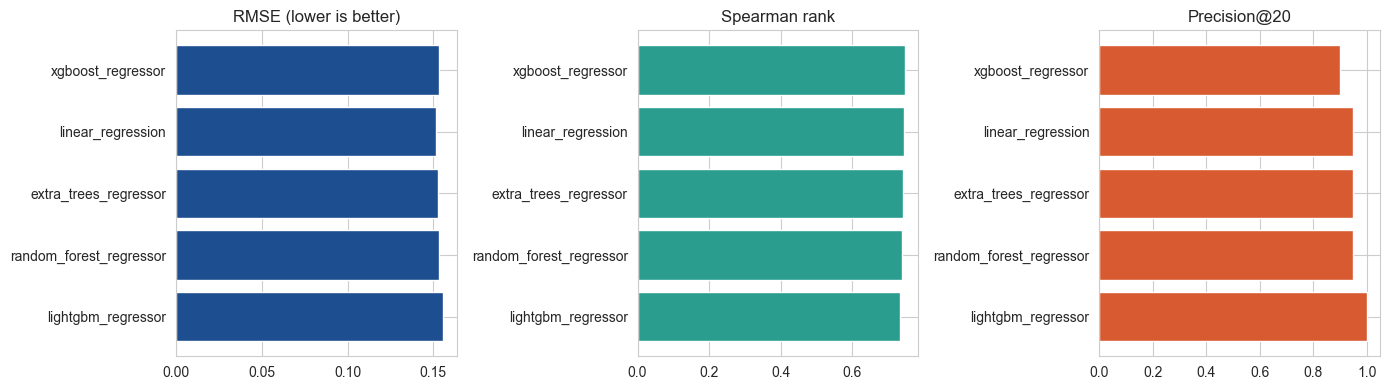

Model comparison saved: content/runs\Indonesia.Batam.Kuliner.202406162232\reports\model_comparison.csv


In [53]:
from IPython.display import display
import matplotlib.pyplot as plt
import os

metrics_df = model_comparison_df.copy()
print("Regression model comparison:")
display(metrics_df)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].barh(metrics_df["model"], metrics_df["rmse"], color="#1D4E8F")
axes[0].set_title("RMSE (lower is better)")
axes[1].barh(metrics_df["model"], metrics_df["spearman_rank"], color="#2A9D8F")
axes[1].set_title("Spearman rank")
axes[2].barh(metrics_df["model"], metrics_df["precision_at_20"], color="#D85A30")
axes[2].set_title("Precision@20")
for ax in axes:
    ax.invert_yaxis()
plt.tight_layout()
comparison_plot_path = os.path.join(REPORT_DIR, "model_comparison.png")
plt.savefig(comparison_plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Model comparison saved: {model_comparison_path}")


Extracting Native Feature Importances for xgboost_regressor...


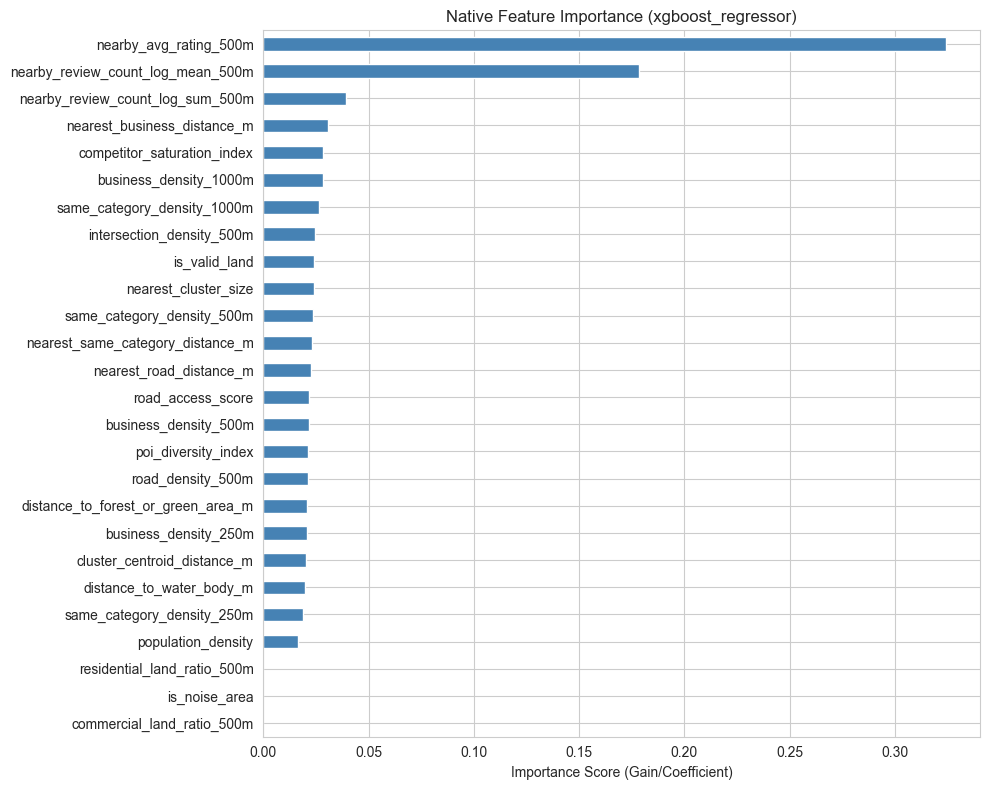


Calculating Scikit-Learn Permutation Importance for xgboost_regressor...


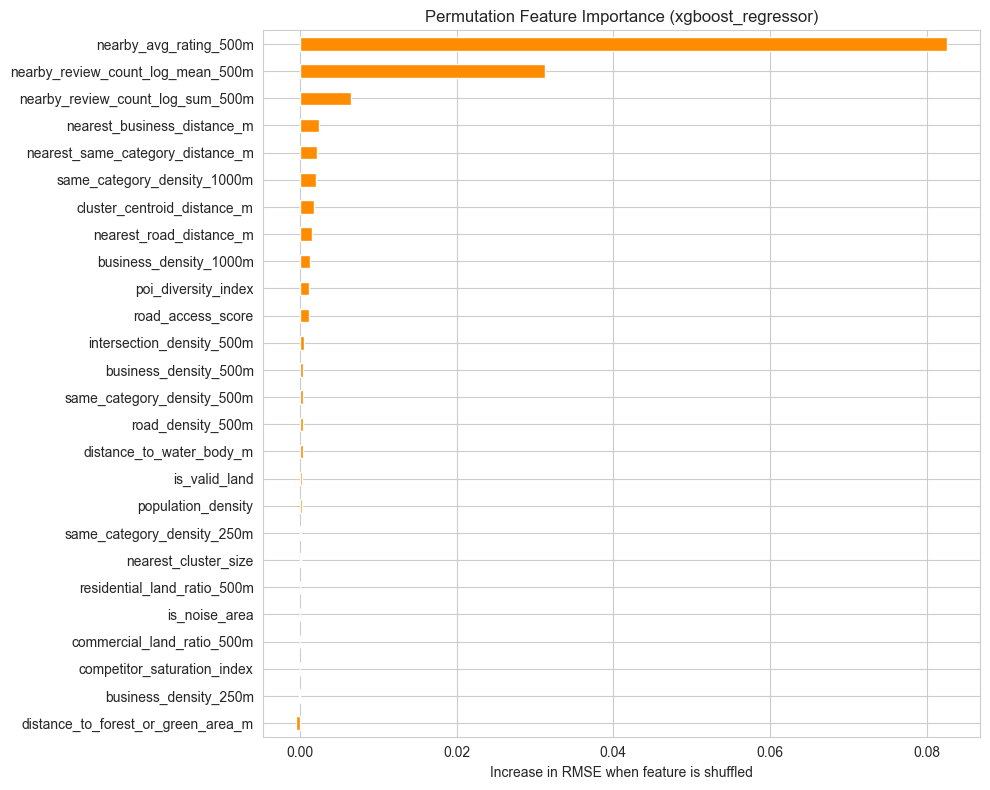

In [56]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.inspection import permutation_importance

# 1. Native Feature Importance (Gain/Impurity based)
print(f"Extracting Native Feature Importances for {best_model_name}...")
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
    feat_names = X_train.columns
elif hasattr(best_model, "named_steps") and hasattr(best_model.named_steps["model"], "coef_"):
    # For Linear Regression in a pipeline
    importances = np.abs(best_model.named_steps["model"].coef_)
    feat_names = X_train.columns
else:
    importances = None

if importances is not None:
    feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=True)
    plt.figure(figsize=(10, 8))
    feat_imp.plot(kind="barh", color="steelblue")
    plt.title(f"Native Feature Importance ({best_model_name})")
    plt.xlabel("Importance Score (Gain/Coefficient)")
    plt.tight_layout()
    plt.show()
else:
    print(f"Native feature importances not directly available for {best_model_name}")

# 2. Scikit-Learn Permutation Feature Importance
print(f"\nCalculating Scikit-Learn Permutation Importance for {best_model_name}...")
# Note: Using X_test and y_test evaluates how features impact generalization
result = permutation_importance(
    best_model, 
    X_test, 
    y_test, 
    n_repeats=10, 
    random_state=RANDOM_SEED, 
    n_jobs=-1,
    scoring='neg_root_mean_squared_error'
)

perm_imp = pd.Series(result.importances_mean, index=X_test.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
perm_imp.plot(kind="barh", color="darkorange")
plt.title(f"Permutation Feature Importance ({best_model_name})")
plt.xlabel("Increase in RMSE when feature is shuffled")
plt.tight_layout()
plt.show()


### 11.7 SHAP Explainability (Global + Local)

Ringkas: interpretasi global dan contoh lokal prediksi.

SHAP global importance:


,feature,mean_abs_shap
0,nearby_avg_rating_500m,0.101857
1,nearby_review_count_log_mean_500m,0.060678
2,same_category_density_1000m,0.013197
3,nearest_road_distance_m,0.012402
4,cluster_centroid_distance_m,0.009307
5,nearest_business_distance_m,0.009004
6,nearby_review_count_log_sum_500m,0.008208
7,business_density_500m,0.007570
8,business_density_1000m,0.006570
9,poi_diversity_index,0.006057


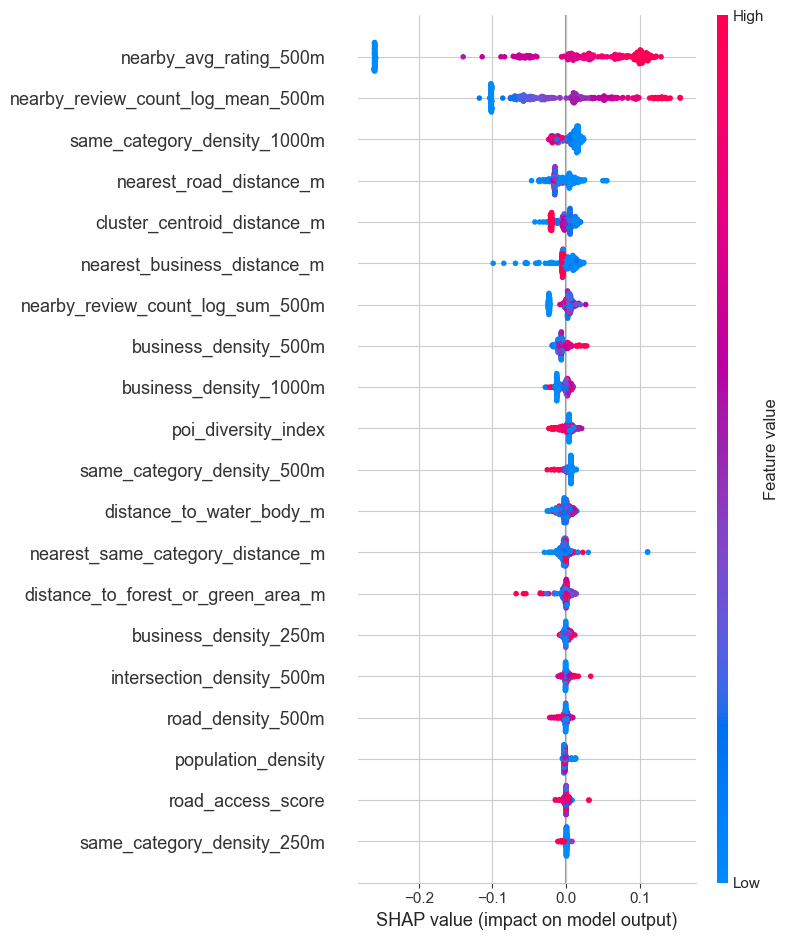

SHAP outputs saved: content/runs\Indonesia.Batam.Kuliner.202406162232\reports\reg_shap_summary.png, content/runs\Indonesia.Batam.Kuliner.202406162232\reports\reg_shap_importance.csv


In [54]:
import os
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt

try:
    import shap
except ImportError:
    shap = None

if shap is None:
    print("SHAP is not installed. Run: %pip install shap")
else:
    max_samples = 300
    X_shap = X_test.sample(max_samples, random_state=RANDOM_SEED) if len(X_test) > max_samples else X_test.copy()
    os.makedirs(REPORT_DIR, exist_ok=True)
    try:
        explainer = shap.TreeExplainer(best_model)
        shap_values = explainer.shap_values(X_shap)
        shap_array = np.asarray(shap_values)
        if shap_array.ndim == 3:
            shap_array = shap_array[:, :, 0]
        shap_importance = pd.Series(np.mean(np.abs(shap_array), axis=0), index=X_shap.columns).sort_values(ascending=False)
        shap_importance_df = shap_importance.reset_index()
        shap_importance_df.columns = ["feature", "mean_abs_shap"]
        print("SHAP global importance:")
        display(shap_importance_df)

        shap.summary_plot(shap_values, X_shap, show=False)
        summary_path = os.path.join(REPORT_DIR, "reg_shap_summary.png")
        plt.tight_layout()
        plt.savefig(summary_path, dpi=150, bbox_inches="tight")
        plt.show()

        shap_importance_path = os.path.join(REPORT_DIR, "reg_shap_importance.csv")
        shap_importance_df.to_csv(shap_importance_path, index=False)
        shap_importance_df.to_csv(os.path.join(REPORT_DIR, "rf_shap_importance.csv"), index=False)
        print(f"SHAP outputs saved: {summary_path}, {shap_importance_path}")
    except Exception as exc:
        print(f"SHAP skipped for {best_model_name}: {exc}")


### 11.8 Simpan Model & Metadata

Ringkas: simpan model RF dan metadata evaluasi.

In [55]:
import os
import glob
import json
import joblib
import datetime

os.makedirs(MODEL_DIR, exist_ok=True)
existing_models = sorted(glob.glob(os.path.join(MODEL_DIR, "reg_location_reco_v*.joblib")))
version = len(existing_models) + 1
model_path = os.path.join(MODEL_DIR, f"reg_location_reco_v{version}.joblib")
joblib.dump(best_model, model_path)

metadata_path = os.path.join(MODEL_DIR, "regression_metadata.json")
legacy_metadata_path = os.path.join(MODEL_DIR, "rf_metadata.json")
regression_metadata = {
    "notebook": "02_regression_location_recommendation",
    "timestamp": datetime.datetime.now().isoformat(),
    "target_db": TARGET_DB_FILE,
    "run_dir": RUN_DIR,
    "model_path": model_path,
    "model_type": "regression",
    "selected_model": best_model_name,
    "feature_schema_version": FEATURE_SCHEMA_VERSION,
    "features": model_feature_cols,
    "suitability_band_thresholds": suitability_band_thresholds,
    "parameters": {
        "random_seed": RANDOM_SEED,
        "spatial_split": "grid_1km_group_shuffle",
        "selection_metric_order": ["spearman_rank", "precision_at_20", "rmse"],
    },
    "metrics": {
        "model_comparison": model_comparison_df.to_dict(orient="records"),
        "best_model": model_comparison_df.iloc[0].to_dict(),
    },
}

with open(metadata_path, "w") as f:
    json.dump(regression_metadata, f, indent=2)
with open(legacy_metadata_path, "w") as f:
    json.dump(regression_metadata, f, indent=2)

active_path = os.path.join(MODEL_DIR, "active.json")
with open(active_path, "w") as f:
    json.dump({"active_version": version, "model_family": "regression"}, f, indent=2)

print(f"Regression model saved: {model_path}")
print(f"Regression metadata saved: {metadata_path}")


Regression model saved: content/runs\Indonesia.Batam.Kuliner.202406162232\models\reg_location_reco_v2.joblib
Regression metadata saved: content/runs\Indonesia.Batam.Kuliner.202406162232\models\regression_metadata.json
